<a href="https://www.kaggle.com/code/omborse771924/global-country-indices-analysis-eda-100-accuracy?scriptVersionId=338143071" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ashyou09/global-country-indices-real-database-2000-2026/global_country_rankings_2000_2026.csv


## Loading Dataset

In [2]:
df = pd.read_csv('/kaggle/input/datasets/ashyou09/global-country-indices-real-database-2000-2026/global_country_rankings_2000_2026.csv')

In [3]:
df.head()

,Country,Year,Region,Economic_Tier,Happiness_Rank,Global_Hunger_Rank,Human_Development_Rank,GDP_Per_Capita_Rank,Life_Expectancy_Rank,Corruption_Perception_Rank,Democracy_Rank,Gini_Rank,Press_Freedom_Rank,Global_Peace_Rank,Environmental_Performance_Rank
0,Afghanistan,2000,Asia,4,195,208,187,212,186,185,215,183,214,216,212
1,Afghanistan,2001,Asia,4,198,207,188,215,186,185,215,180,214,217,214
2,Afghanistan,2002,Asia,4,196,208,192,213,185,185,215,174,214,217,213
3,Afghanistan,2003,Asia,4,196,207,195,214,183,185,215,173,214,217,214
4,Afghanistan,2004,Asia,4,194,210,197,214,183,185,216,172,214,217,212


In [4]:
df.tail()

,Country,Year,Region,Economic_Tier,Happiness_Rank,Global_Hunger_Rank,Human_Development_Rank,GDP_Per_Capita_Rank,Life_Expectancy_Rank,Corruption_Perception_Rank,Democracy_Rank,Gini_Rank,Press_Freedom_Rank,Global_Peace_Rank,Environmental_Performance_Rank
5854,Zimbabwe,2022,Africa,3,167,173,180,165,200,164,182,208,162,163,186
5855,Zimbabwe,2023,Africa,3,167,173,182,171,200,163,183,209,162,162,186
5856,Zimbabwe,2024,Africa,3,168,173,180,170,200,163,183,210,162,163,187
5857,Zimbabwe,2025,Africa,3,170,173,180,170,200,163,183,210,162,162,186
5858,Zimbabwe,2026,Africa,3,167,173,180,170,200,163,183,210,162,162,187


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5859 entries, 0 to 5858
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   Country                         5859 non-null   object
 1   Year                            5859 non-null   int64 
 2   Region                          5859 non-null   object
 3   Economic_Tier                   5859 non-null   int64 
 4   Happiness_Rank                  5859 non-null   int64 
 5   Global_Hunger_Rank              5859 non-null   int64 
 6   Human_Development_Rank          5859 non-null   int64 
 7   GDP_Per_Capita_Rank             5859 non-null   int64 
 8   Life_Expectancy_Rank            5859 non-null   int64 
 9   Corruption_Perception_Rank      5859 non-null   int64 
 10  Democracy_Rank                  5859 non-null   int64 
 11  Gini_Rank                       5859 non-null   int64 
 12  Press_Freedom_Rank              5859 non-null   

In [6]:
df.describe(
    
)

,Year,Economic_Tier,Happiness_Rank,Global_Hunger_Rank,Human_Development_Rank,GDP_Per_Capita_Rank,Life_Expectancy_Rank,Corruption_Perception_Rank,Democracy_Rank,Gini_Rank,Press_Freedom_Rank,Global_Peace_Rank,Environmental_Performance_Rank
count,5859.000000,5859.000000,5859.000000,5859.000000,5859.000000,5859.000000,5859.000000,5859.000000,5859.000000,5859.000000,5859.000000,5859.000000,5859.000000
mean,2013.000000,2.050691,109.000000,96.936849,108.586790,108.971155,108.995904,109.000000,109.000000,108.951528,109.000000,109.000000,109.000000
std,7.789546,1.035058,62.647186,75.533151,62.031375,62.689388,62.649583,62.647186,62.647186,62.672195,62.647186,62.647186,62.647186
min,2000.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2006.000000,1.000000,55.000000,1.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000
50%,2013.000000,2.000000,109.000000,109.000000,109.000000,109.000000,109.000000,109.000000,109.000000,109.000000,109.000000,109.000000,109.000000
75%,2020.000000,3.000000,163.000000,163.000000,163.000000,163.000000,163.000000,163.000000,163.000000,163.000000,163.000000,163.000000,163.000000
max,2026.000000,4.000000,217.000000,217.000000,217.000000,217.000000,217.000000,217.000000,217.000000,217.000000,217.000000,217.000000,217.000000


In [7]:
df.isnull()

,Country,Year,Region,Economic_Tier,Happiness_Rank,Global_Hunger_Rank,Human_Development_Rank,GDP_Per_Capita_Rank,Life_Expectancy_Rank,Corruption_Perception_Rank,Democracy_Rank,Gini_Rank,Press_Freedom_Rank,Global_Peace_Rank,Environmental_Performance_Rank
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5854,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
5855,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
5856,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
5857,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [8]:
df.isnull().sum()


Country                           0
Year                              0
Region                            0
Economic_Tier                     0
Happiness_Rank                    0
Global_Hunger_Rank                0
Human_Development_Rank            0
GDP_Per_Capita_Rank               0
Life_Expectancy_Rank              0
Corruption_Perception_Rank        0
Democracy_Rank                    0
Gini_Rank                         0
Press_Freedom_Rank                0
Global_Peace_Rank                 0
Environmental_Performance_Rank    0
dtype: int64

In [9]:
df.duplicated

<bound method DataFrame.duplicated of           Country  Year  Region  Economic_Tier  Happiness_Rank  \
0     Afghanistan  2000    Asia              4             195   
1     Afghanistan  2001    Asia              4             198   
2     Afghanistan  2002    Asia              4             196   
3     Afghanistan  2003    Asia              4             196   
4     Afghanistan  2004    Asia              4             194   
...           ...   ...     ...            ...             ...   
5854     Zimbabwe  2022  Africa              3             167   
5855     Zimbabwe  2023  Africa              3             167   
5856     Zimbabwe  2024  Africa              3             168   
5857     Zimbabwe  2025  Africa              3             170   
5858     Zimbabwe  2026  Africa              3             167   

      Global_Hunger_Rank  Human_Development_Rank  GDP_Per_Capita_Rank  \
0                    208                     187                  212   
1                    20

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.columns

Index(['Country', 'Year', 'Region', 'Economic_Tier', 'Happiness_Rank',
       'Global_Hunger_Rank', 'Human_Development_Rank', 'GDP_Per_Capita_Rank',
       'Life_Expectancy_Rank', 'Corruption_Perception_Rank', 'Democracy_Rank',
       'Gini_Rank', 'Press_Freedom_Rank', 'Global_Peace_Rank',
       'Environmental_Performance_Rank'],
      dtype='object')

## EDA

DATASET SHAPE
(5859, 15)

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5859 entries, 0 to 5858
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   Country                         5859 non-null   object
 1   Year                            5859 non-null   int64 
 2   Region                          5859 non-null   object
 3   Economic_Tier                   5859 non-null   int64 
 4   Happiness_Rank                  5859 non-null   int64 
 5   Global_Hunger_Rank              5859 non-null   int64 
 6   Human_Development_Rank          5859 non-null   int64 
 7   GDP_Per_Capita_Rank             5859 non-null   int64 
 8   Life_Expectancy_Rank            5859 non-null   int64 
 9   Corruption_Perception_Rank      5859 non-null   int64 
 10  Democracy_Rank                  5859 non-null   int64 
 11  Gini_Rank                       5859 non-null   int64 
 12  Press_Fre

,Country,Year,Region,Economic_Tier,Happiness_Rank,Global_Hunger_Rank,Human_Development_Rank,GDP_Per_Capita_Rank,Life_Expectancy_Rank,Corruption_Perception_Rank,Democracy_Rank,Gini_Rank,Press_Freedom_Rank,Global_Peace_Rank,Environmental_Performance_Rank
0,Afghanistan,2000,Asia,4,195,208,187,212,186,185,215,183,214,216,212
1,Afghanistan,2001,Asia,4,198,207,188,215,186,185,215,180,214,217,214
2,Afghanistan,2002,Asia,4,196,208,192,213,185,185,215,174,214,217,213
3,Afghanistan,2003,Asia,4,196,207,195,214,183,185,215,173,214,217,214
4,Afghanistan,2004,Asia,4,194,210,197,214,183,185,216,172,214,217,212



LAST 5 ROWS


,Country,Year,Region,Economic_Tier,Happiness_Rank,Global_Hunger_Rank,Human_Development_Rank,GDP_Per_Capita_Rank,Life_Expectancy_Rank,Corruption_Perception_Rank,Democracy_Rank,Gini_Rank,Press_Freedom_Rank,Global_Peace_Rank,Environmental_Performance_Rank
5854,Zimbabwe,2022,Africa,3,167,173,180,165,200,164,182,208,162,163,186
5855,Zimbabwe,2023,Africa,3,167,173,182,171,200,163,183,209,162,162,186
5856,Zimbabwe,2024,Africa,3,168,173,180,170,200,163,183,210,162,163,187
5857,Zimbabwe,2025,Africa,3,170,173,180,170,200,163,183,210,162,162,186
5858,Zimbabwe,2026,Africa,3,167,173,180,170,200,163,183,210,162,162,187



MISSING VALUES


Country                           0
Year                              0
Region                            0
Economic_Tier                     0
Happiness_Rank                    0
Global_Hunger_Rank                0
Human_Development_Rank            0
GDP_Per_Capita_Rank               0
Life_Expectancy_Rank              0
Corruption_Perception_Rank        0
Democracy_Rank                    0
Gini_Rank                         0
Press_Freedom_Rank                0
Global_Peace_Rank                 0
Environmental_Performance_Rank    0
dtype: int64


Duplicate Rows : 0

Statistical Summary


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Country,5859,217,Afghanistan,27,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,5859.0,NaN,NaN,NaN,2013.0,7.789546,2000.0,2006.0,2013.0,2020.0,2026.0
Region,5859,5,Asia,1782,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Economic_Tier,5859.0,NaN,NaN,NaN,2.050691,1.035058,1.0,1.0,2.0,3.0,4.0
Happiness_Rank,5859.0,NaN,NaN,NaN,109.0,62.647186,1.0,55.0,109.0,163.0,217.0
Global_Hunger_Rank,5859.0,NaN,NaN,NaN,96.936849,75.533151,1.0,1.0,109.0,163.0,217.0
Human_Development_Rank,5859.0,NaN,NaN,NaN,108.58679,62.031375,1.0,55.0,109.0,163.0,217.0
GDP_Per_Capita_Rank,5859.0,NaN,NaN,NaN,108.971155,62.689388,1.0,55.0,109.0,163.0,217.0
Life_Expectancy_Rank,5859.0,NaN,NaN,NaN,108.995904,62.649583,1.0,55.0,109.0,163.0,217.0
Corruption_Perception_Rank,5859.0,NaN,NaN,NaN,109.0,62.647186,1.0,55.0,109.0,163.0,217.0



Numeric Columns
['Year', 'Economic_Tier', 'Happiness_Rank', 'Global_Hunger_Rank', 'Human_Development_Rank', 'GDP_Per_Capita_Rank', 'Life_Expectancy_Rank', 'Corruption_Perception_Rank', 'Democracy_Rank', 'Gini_Rank', 'Press_Freedom_Rank', 'Global_Peace_Rank', 'Environmental_Performance_Rank']

Categorical Columns
['Country', 'Region']


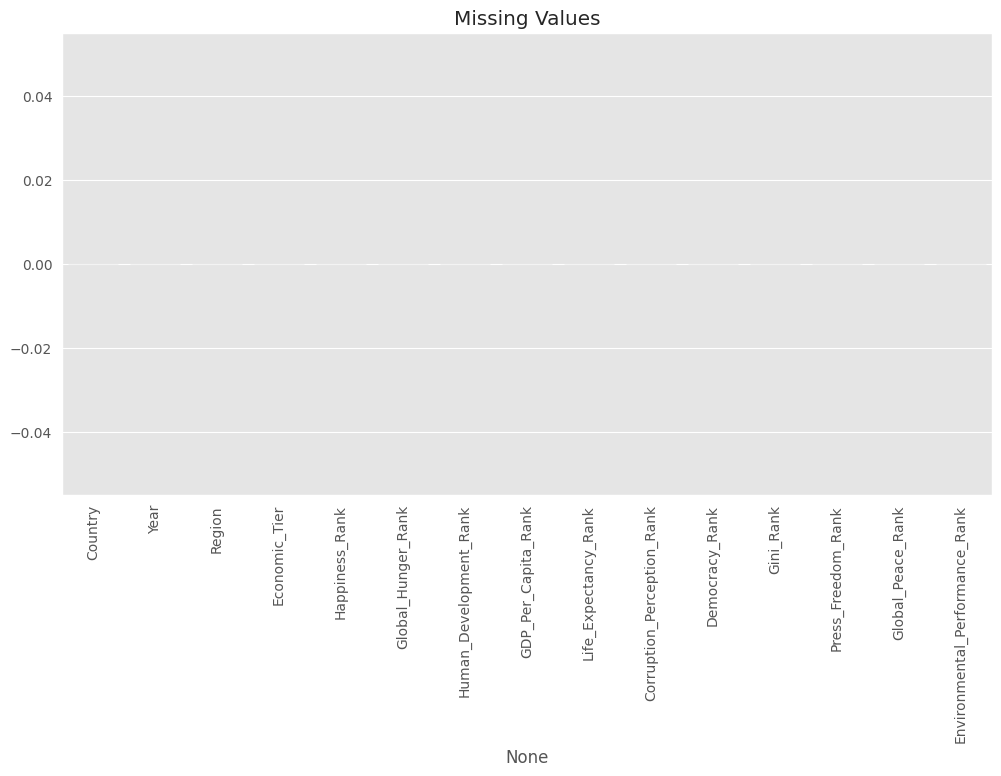

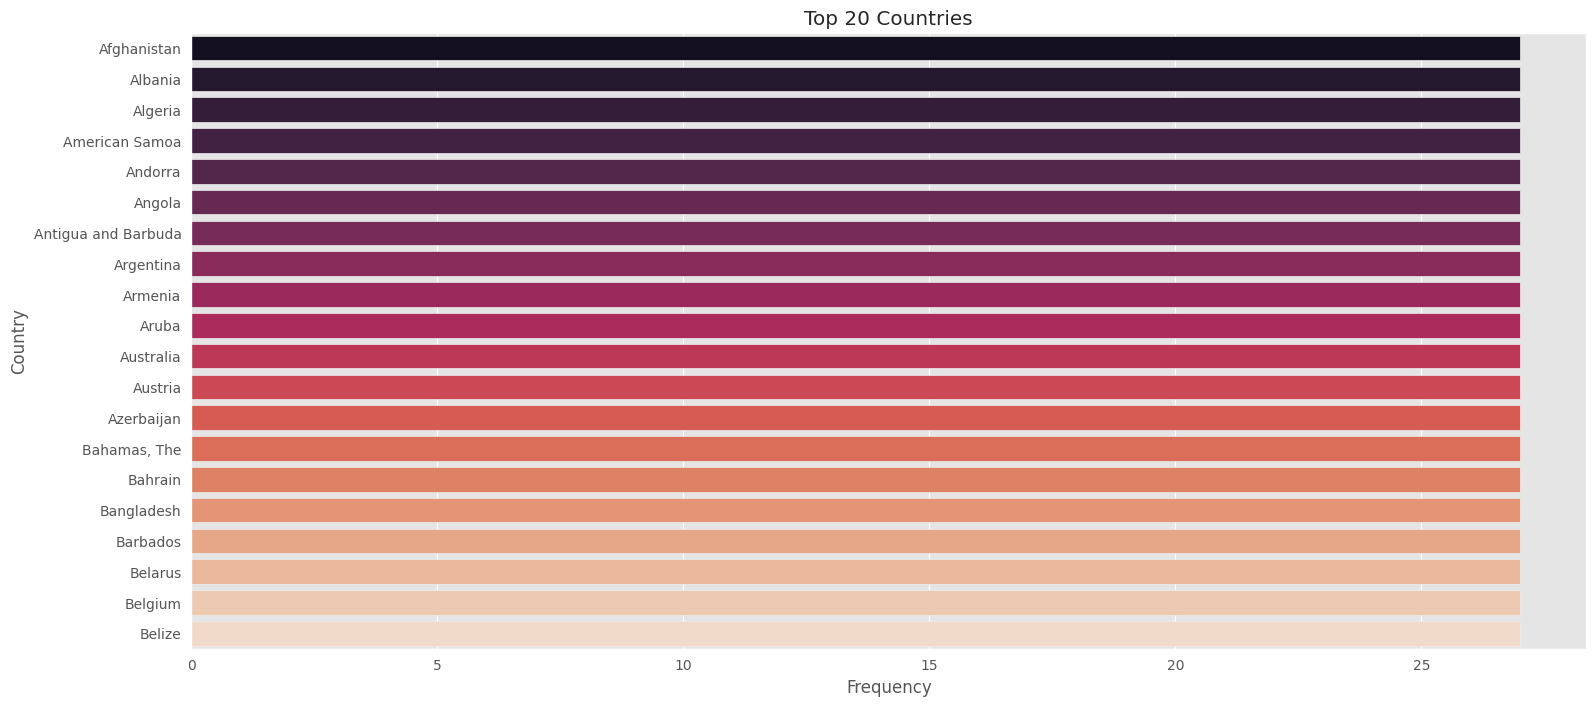

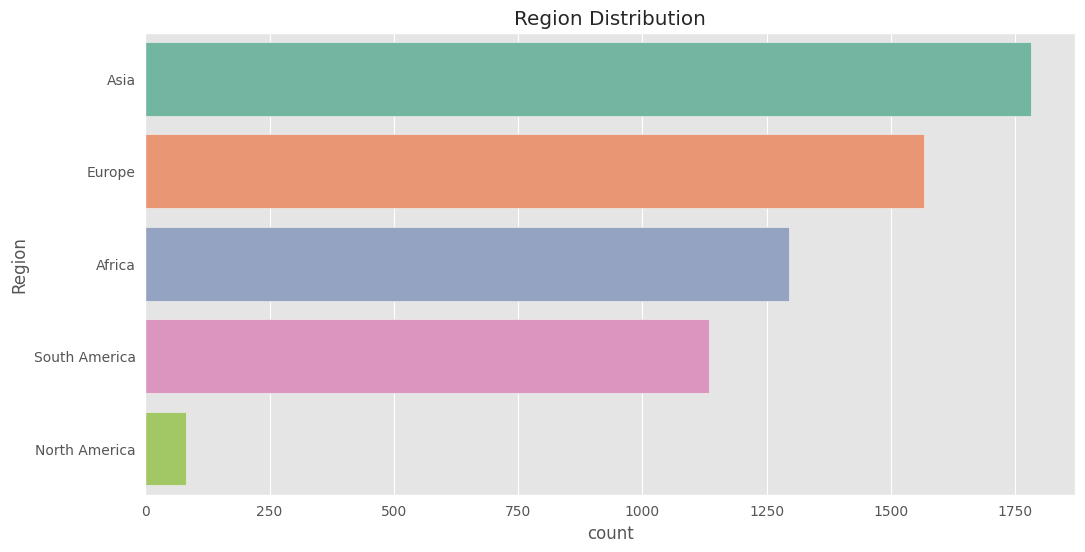

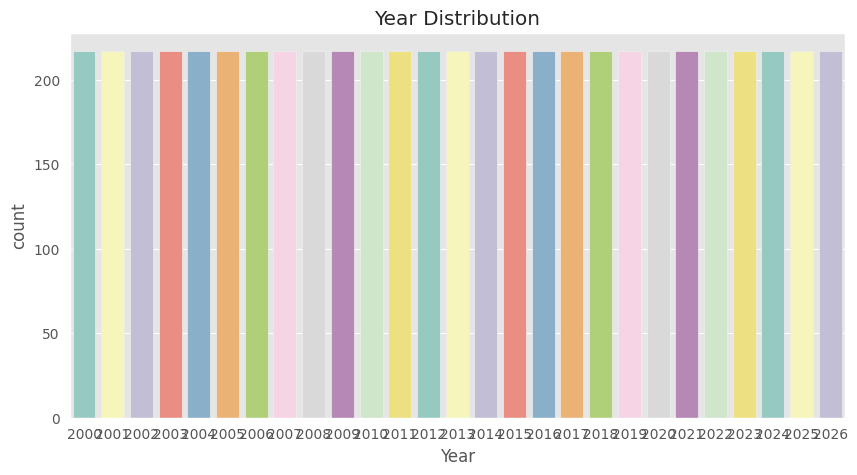

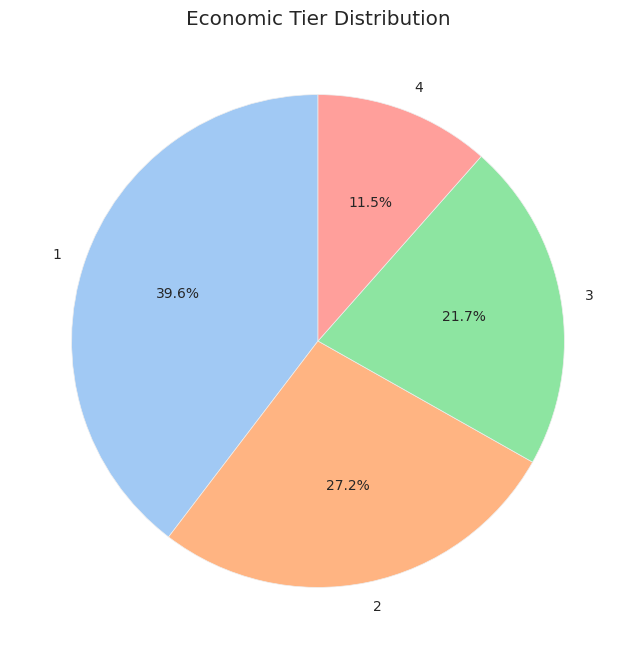

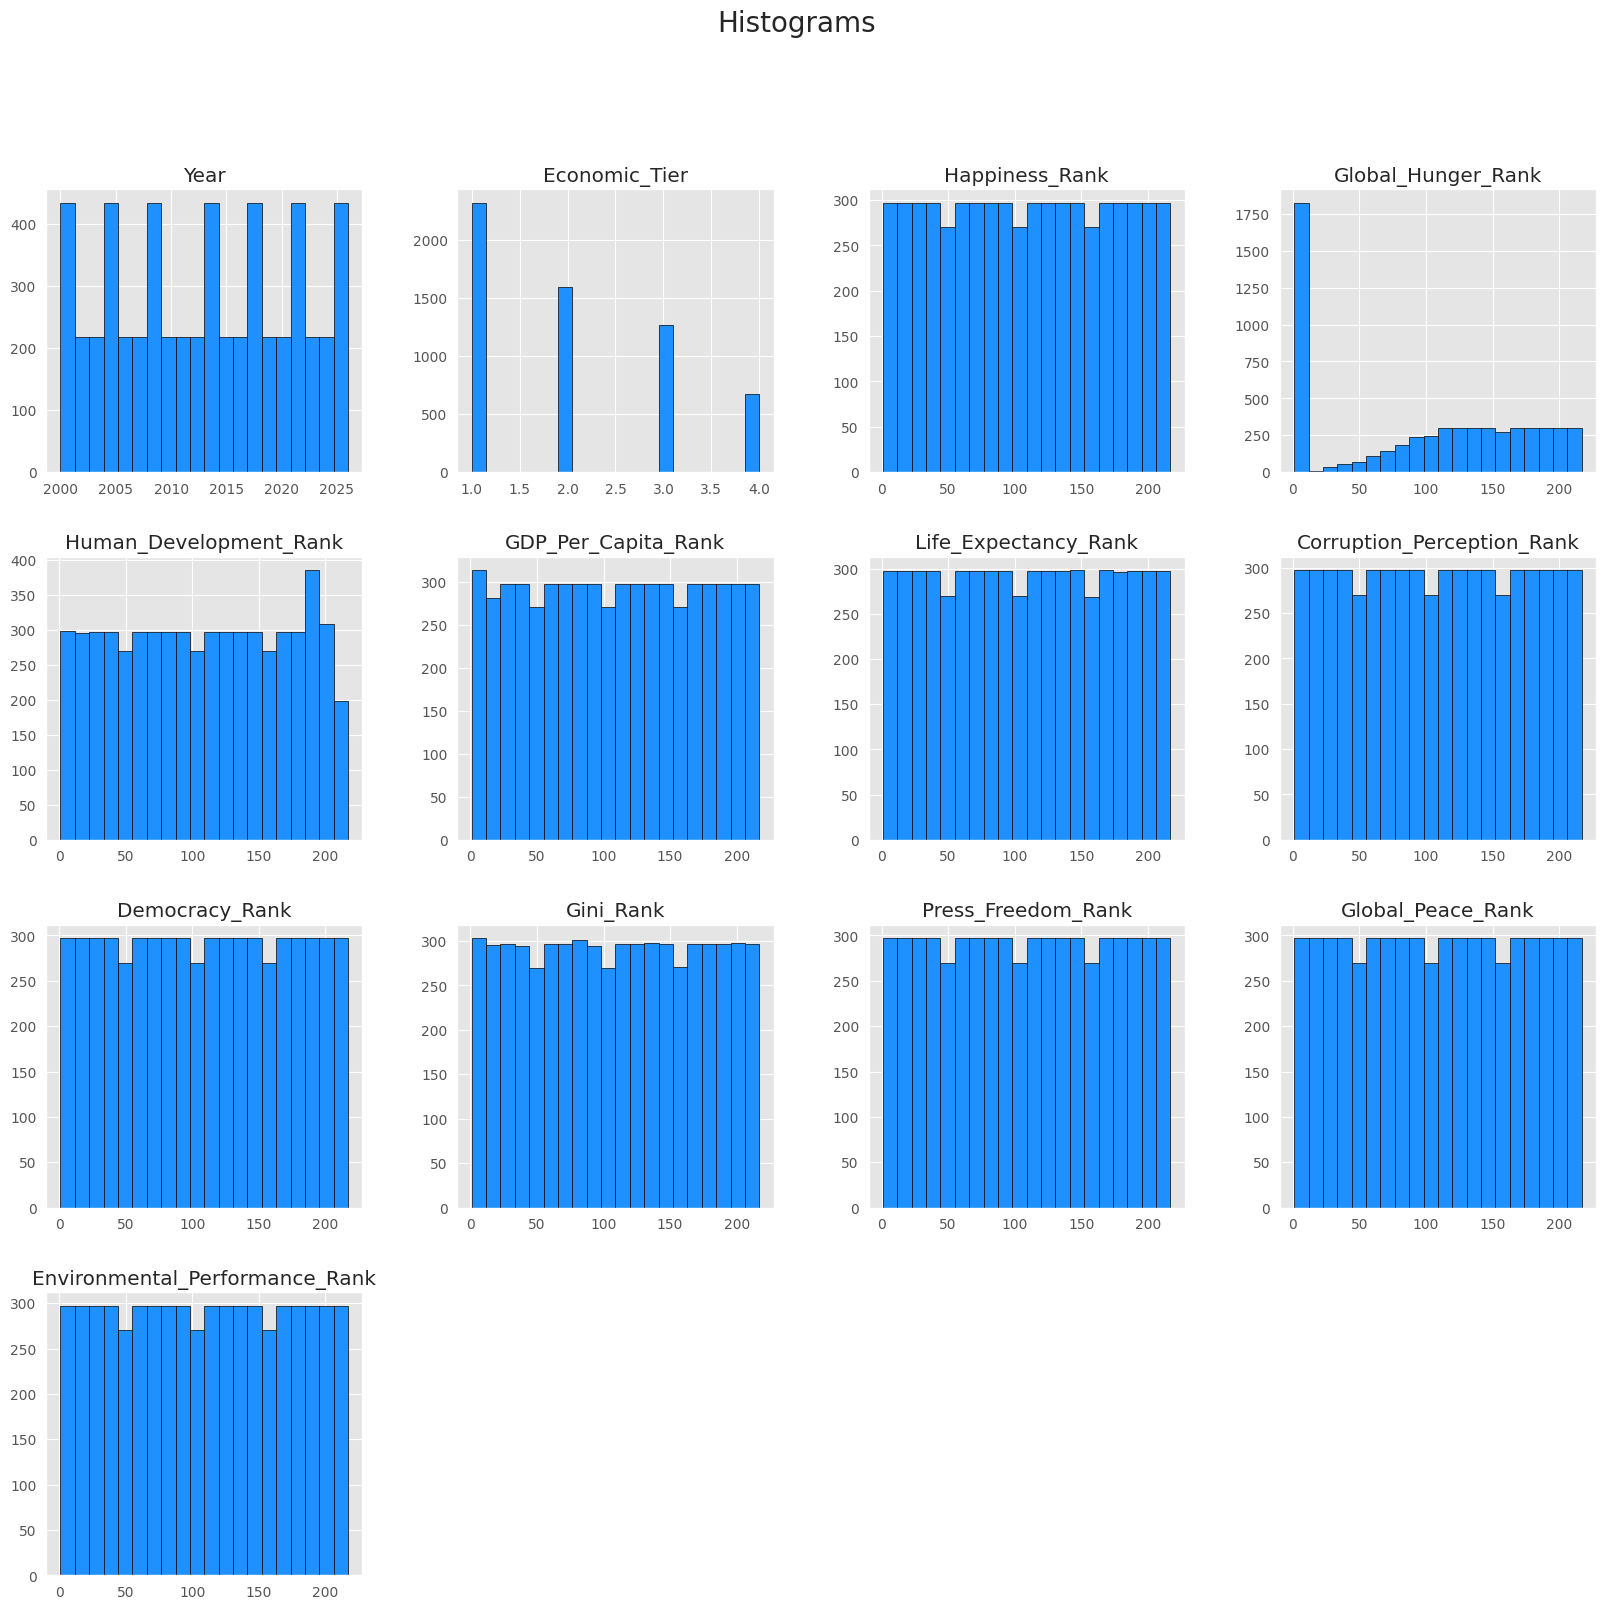

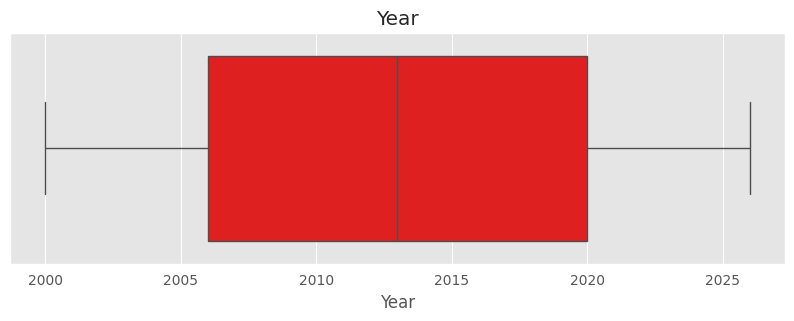

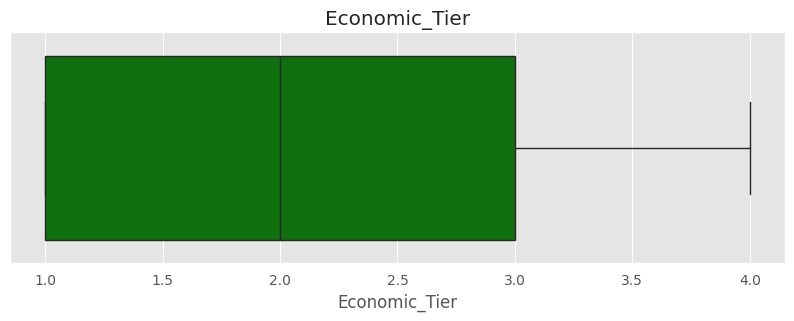

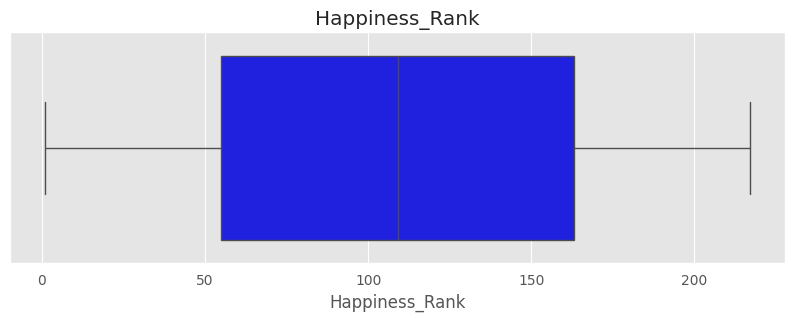

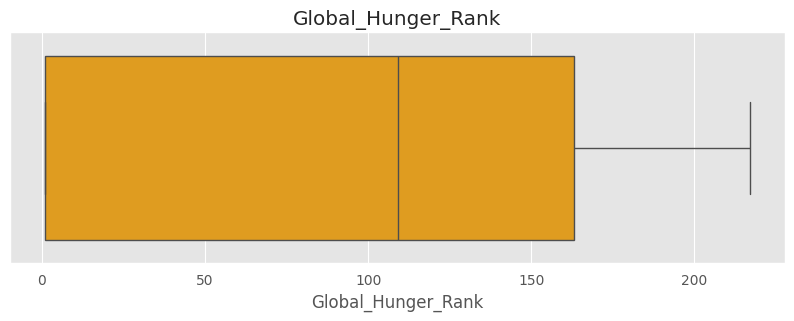

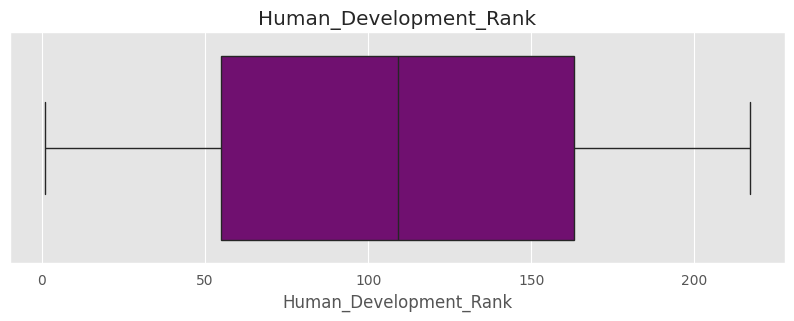

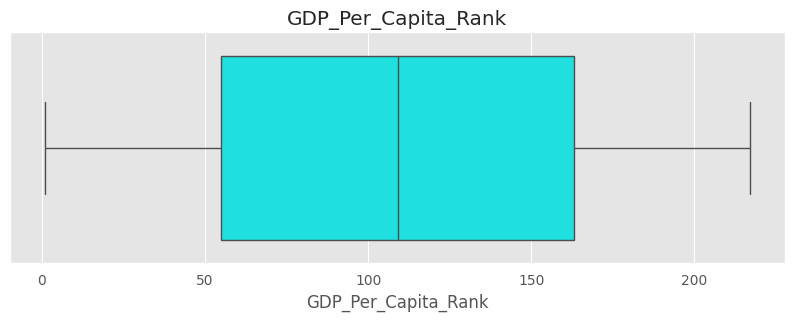

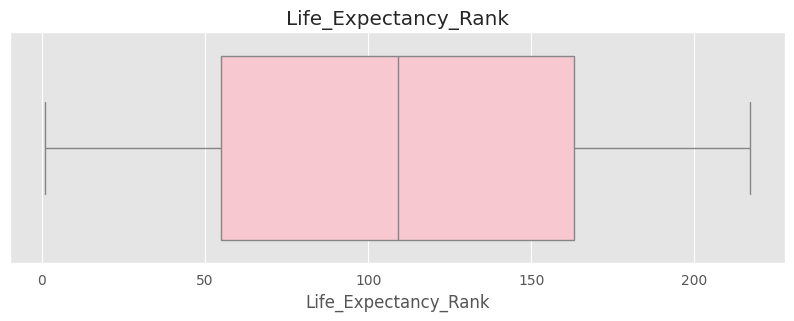

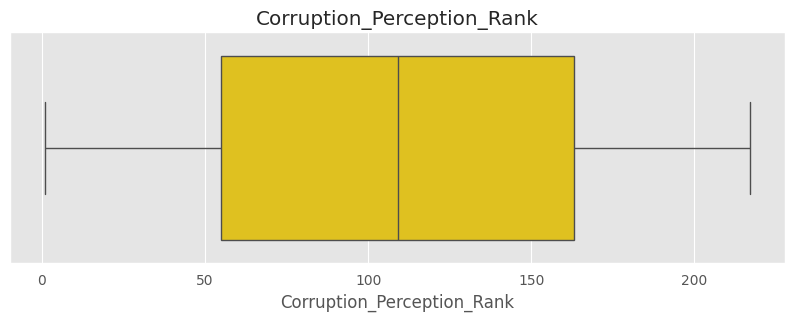

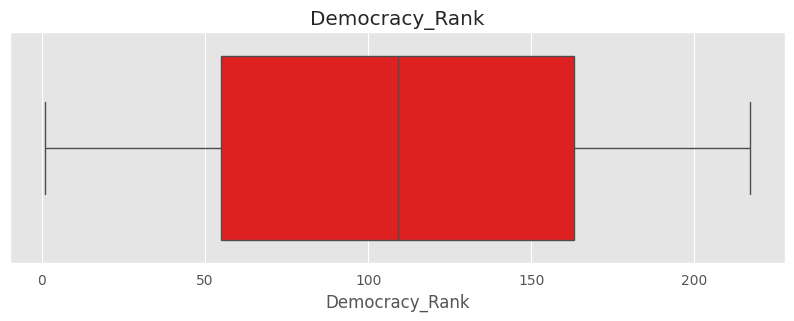

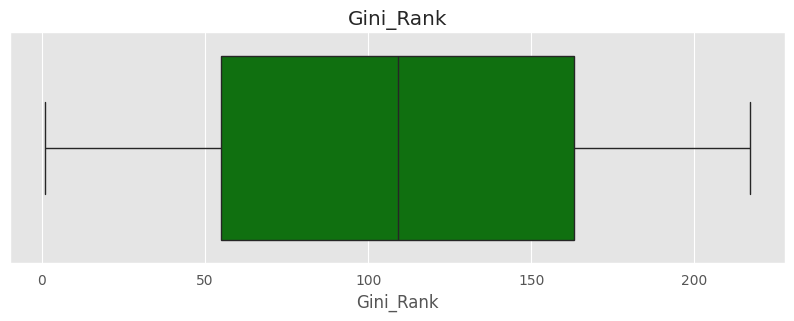

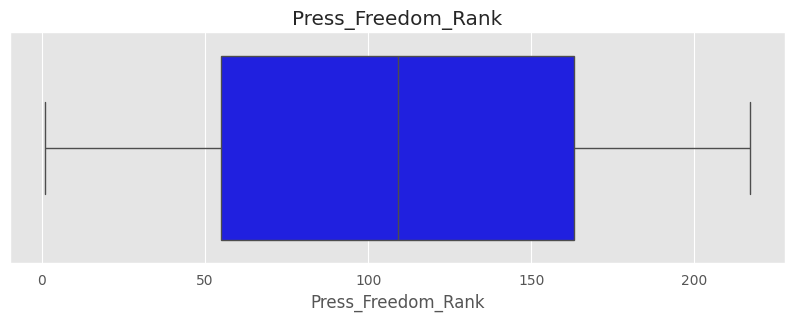

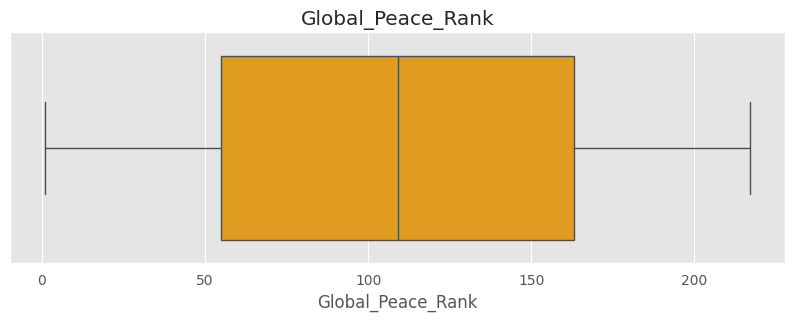

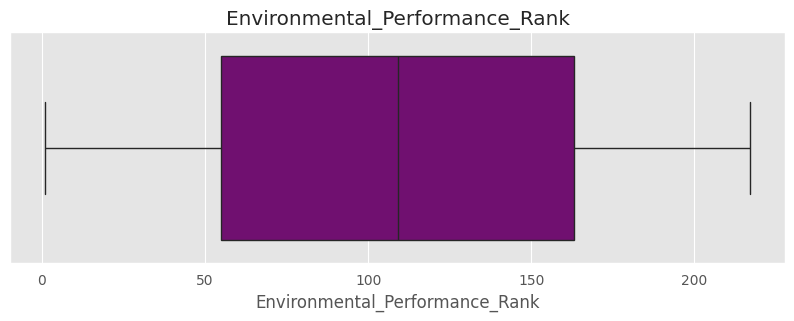

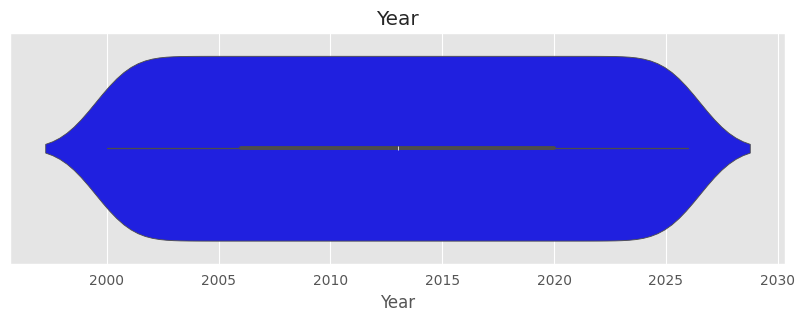

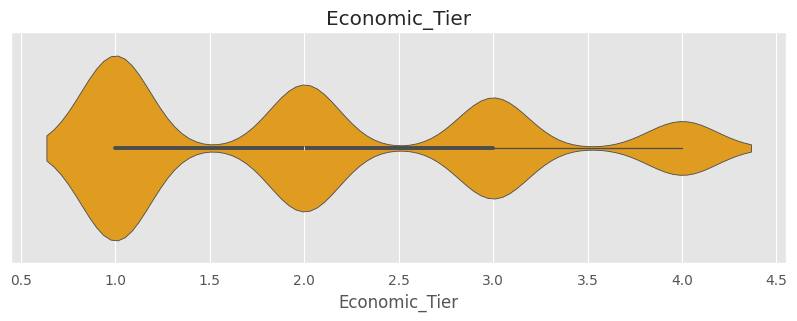

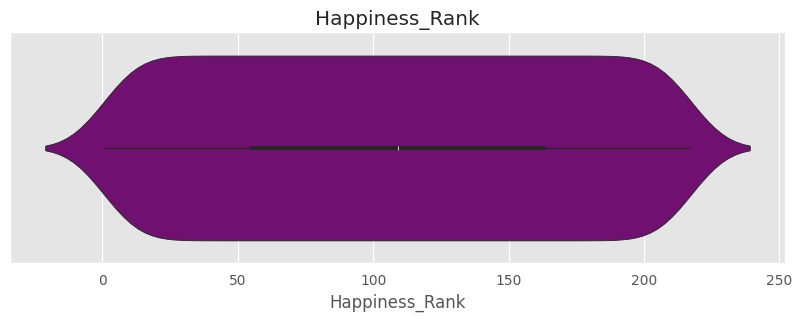

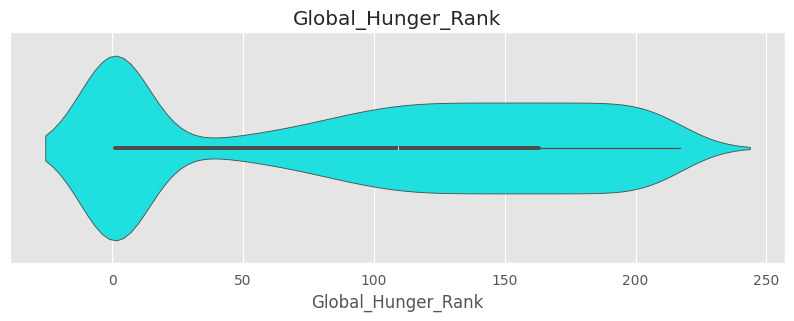

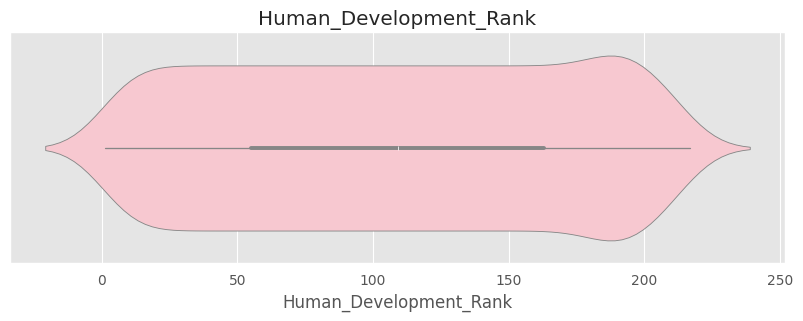

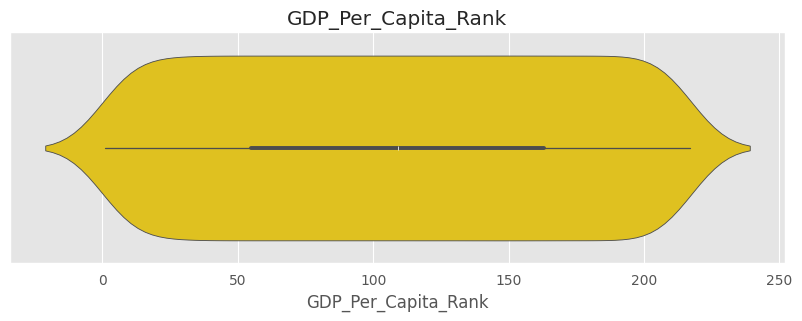

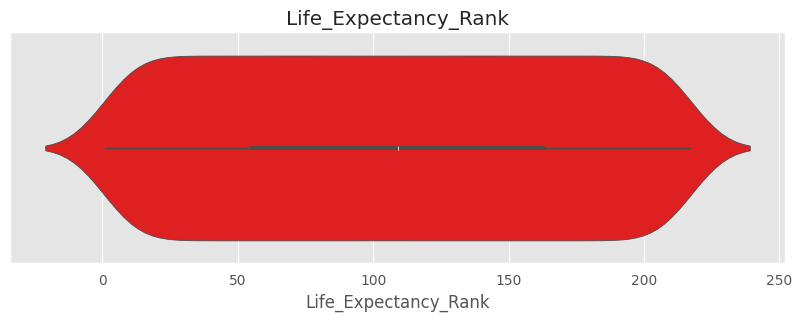

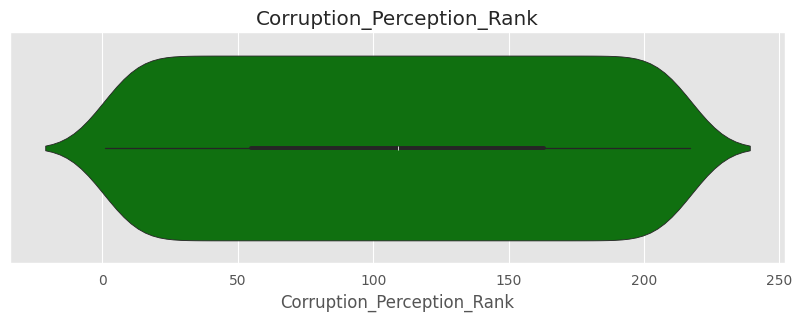

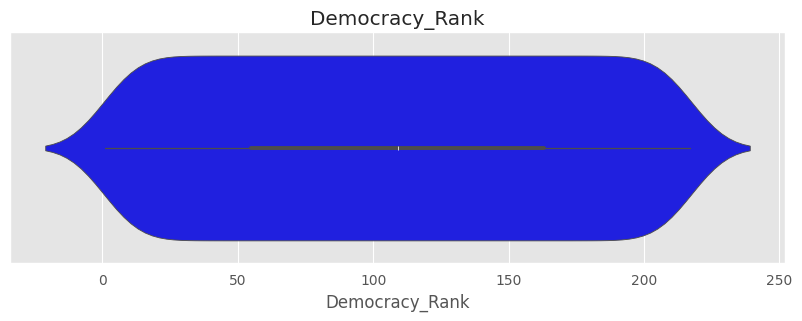

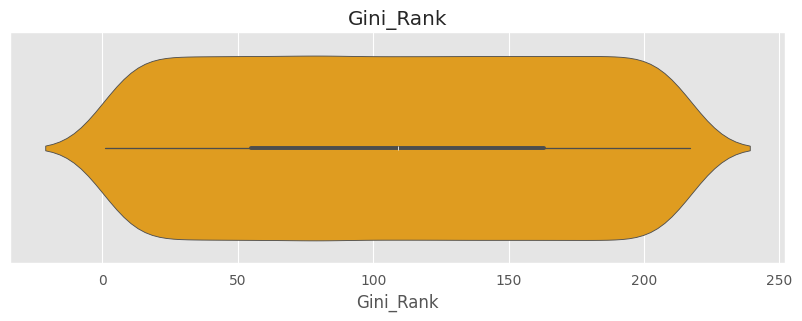

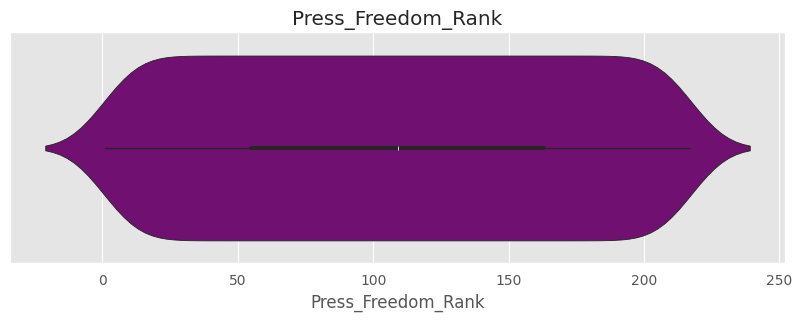

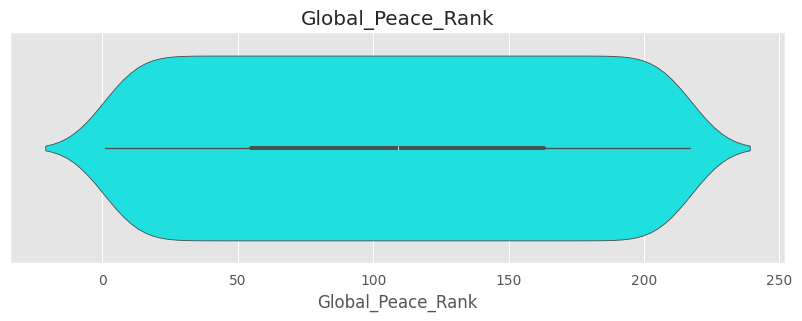

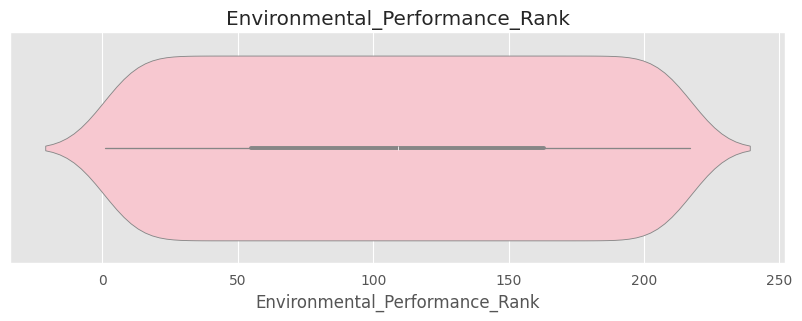

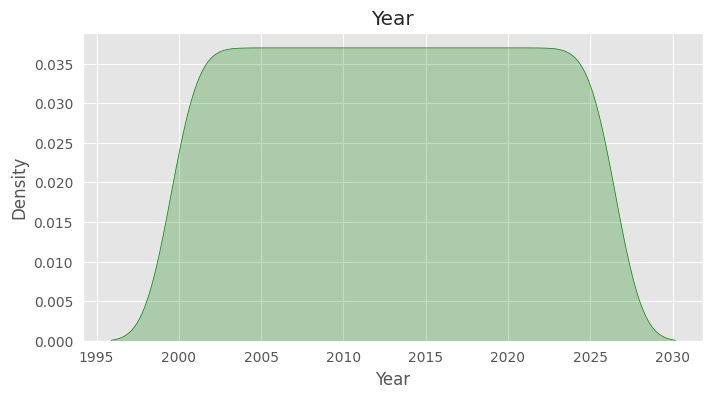

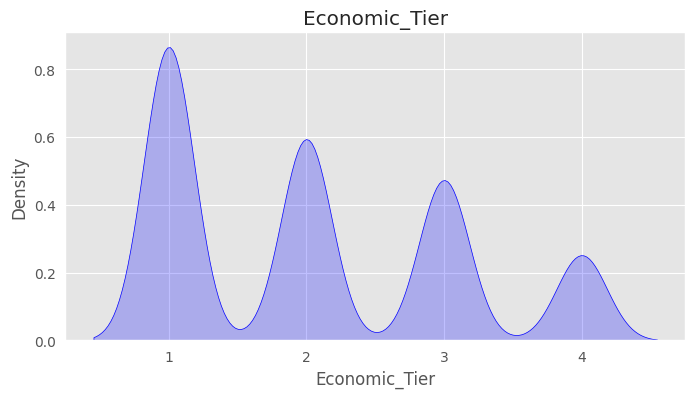

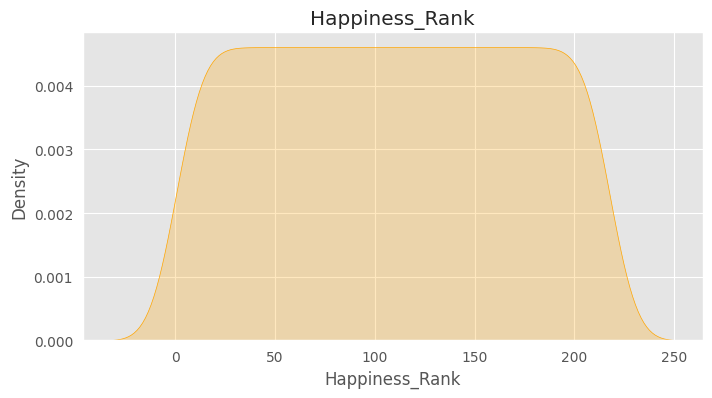

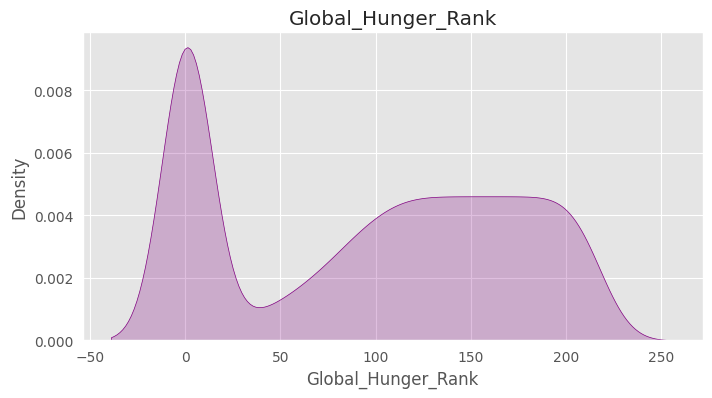

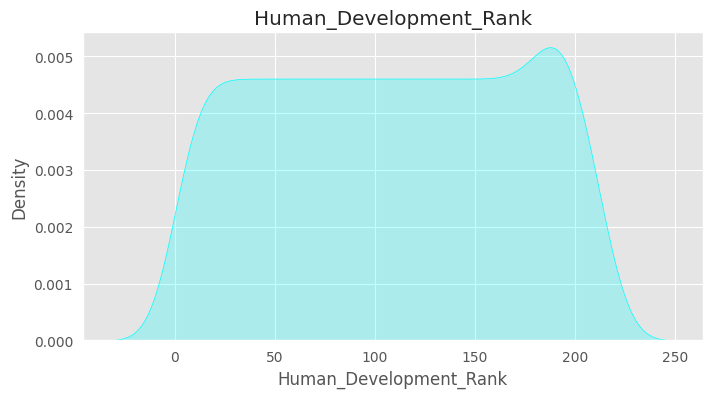

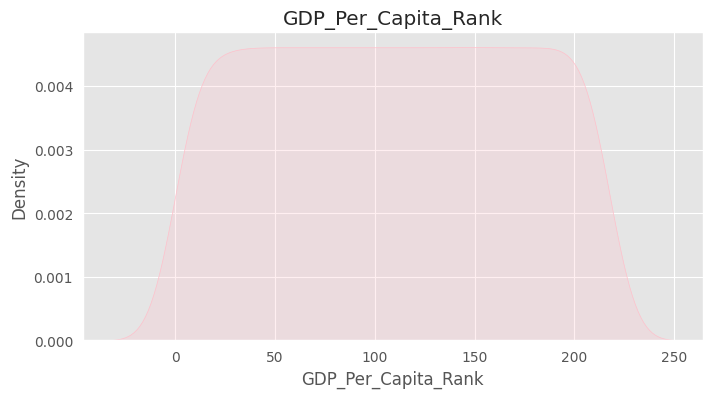

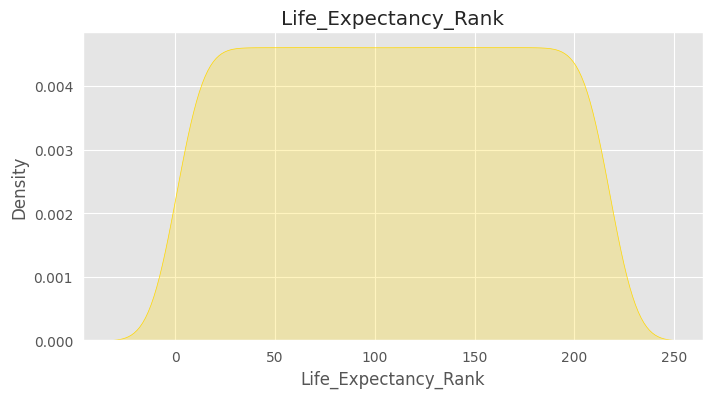

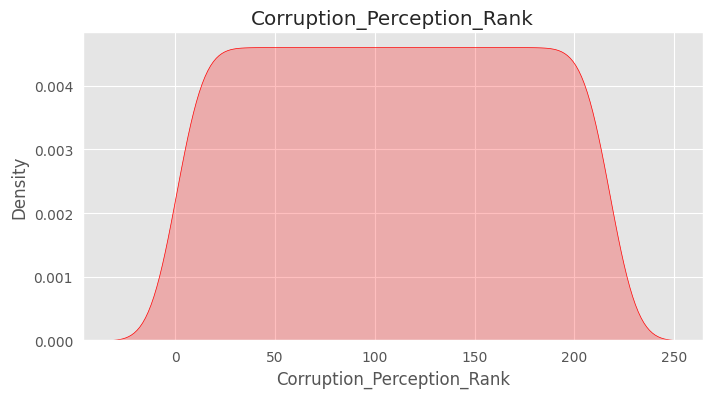

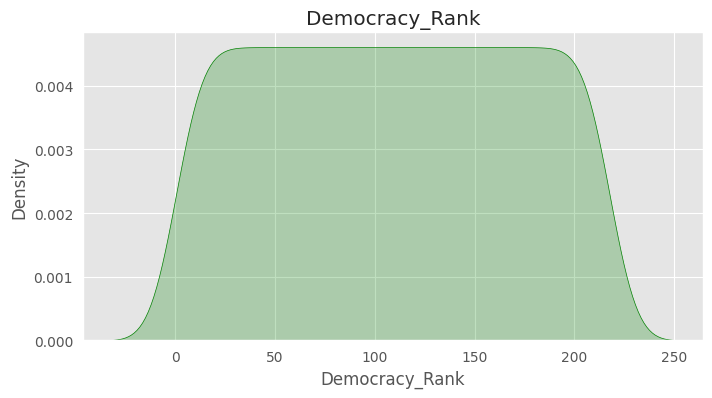

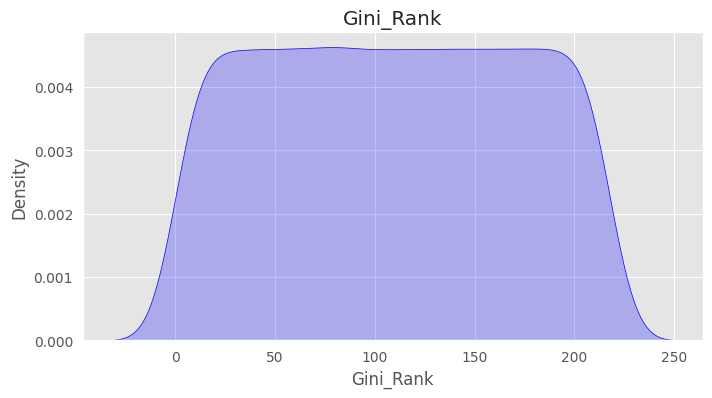

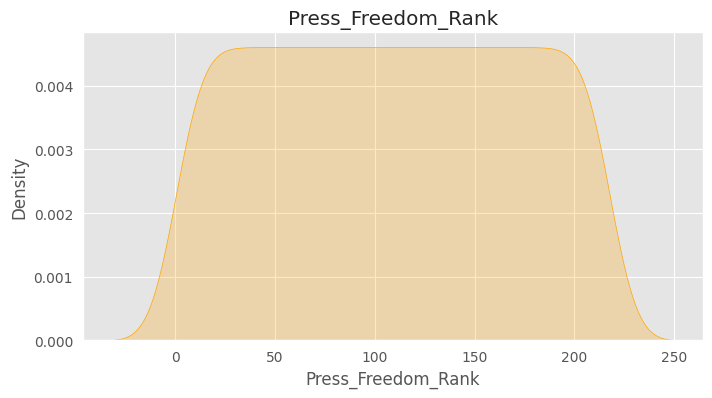

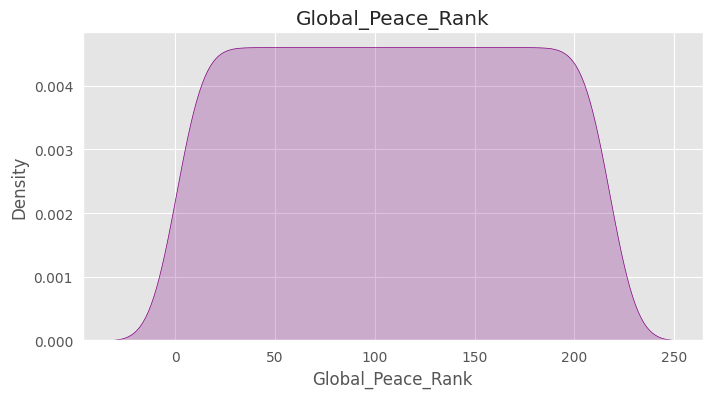

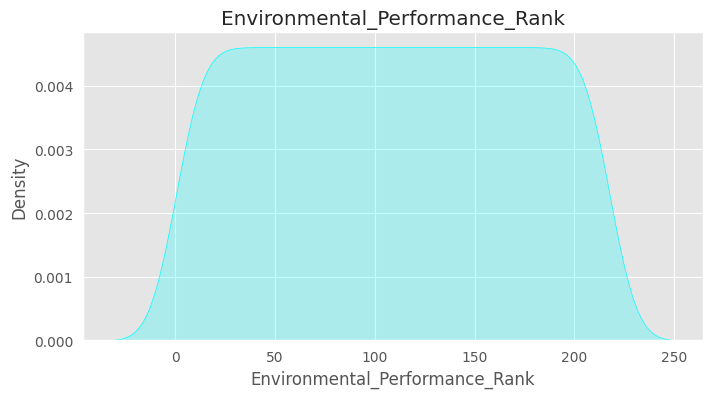

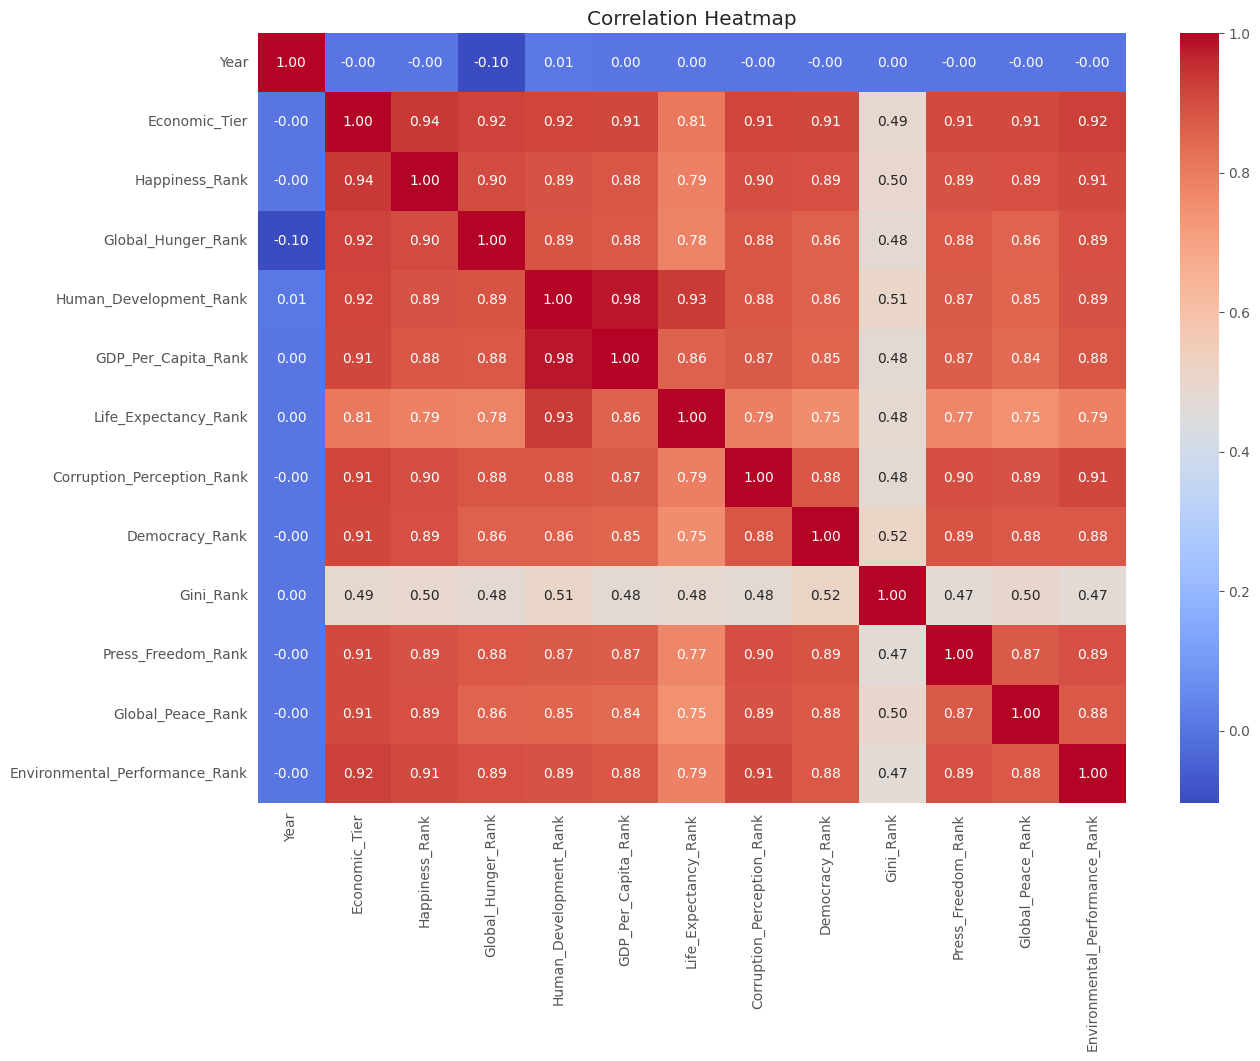

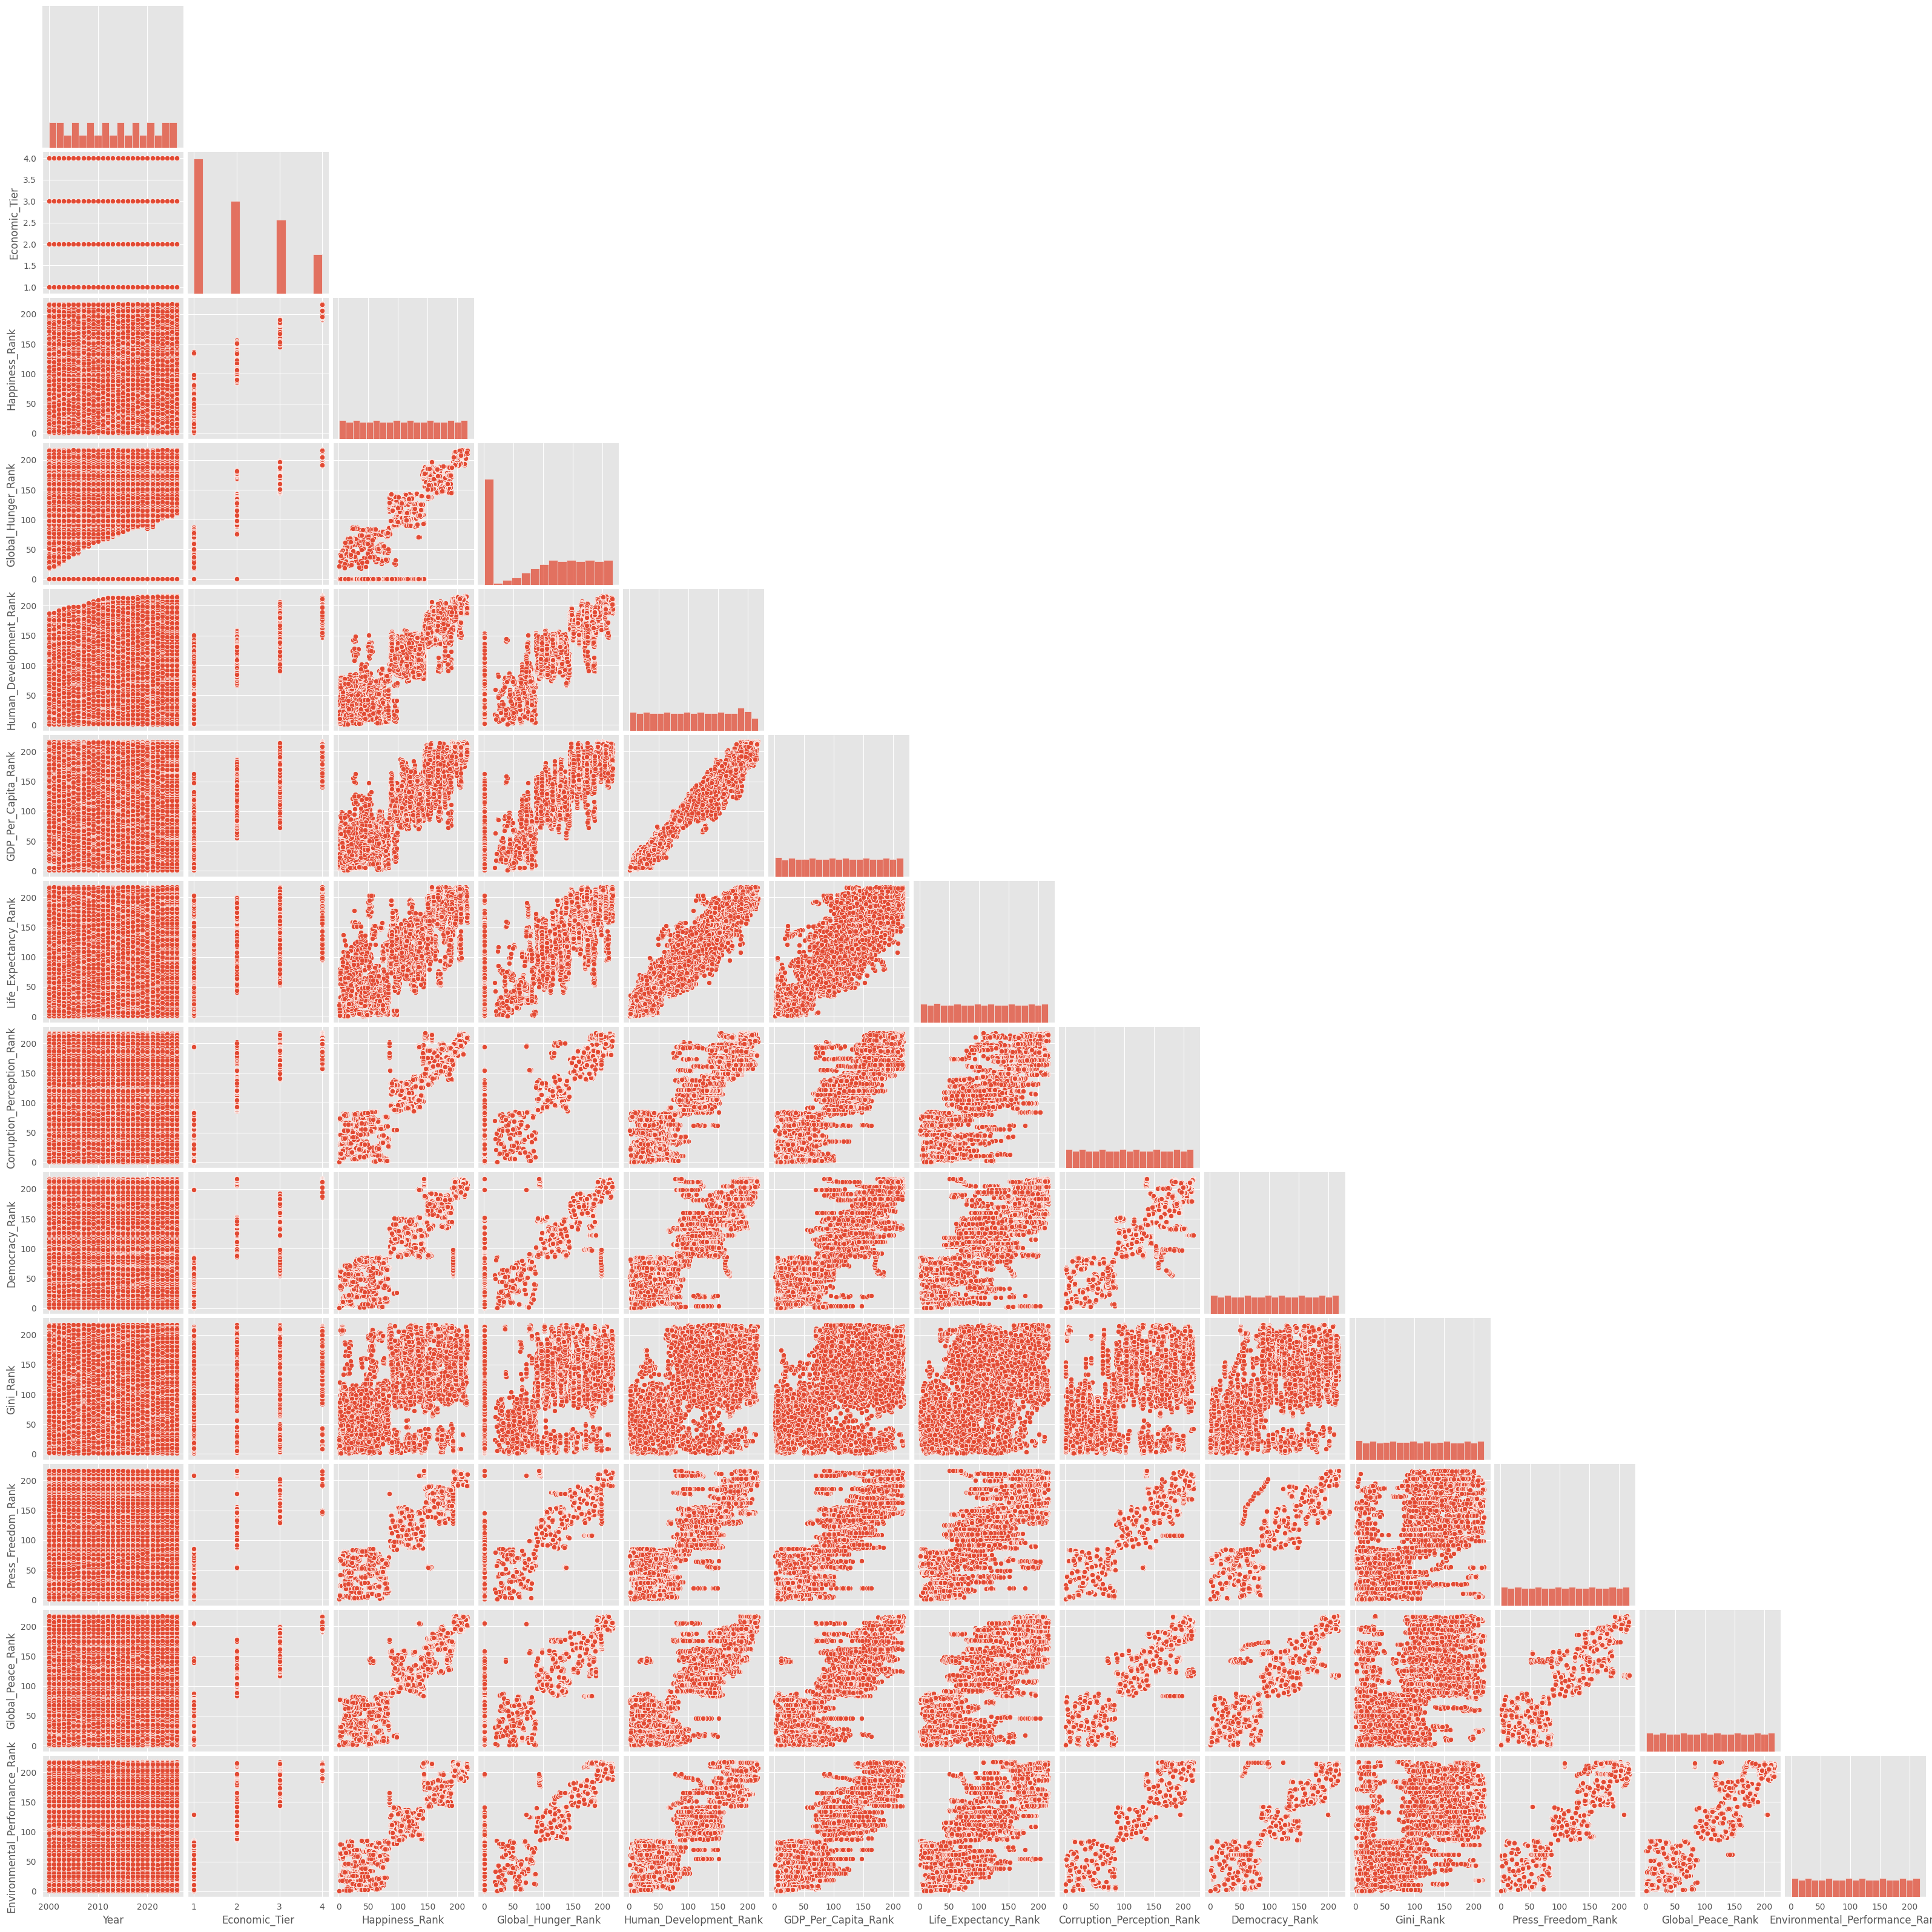

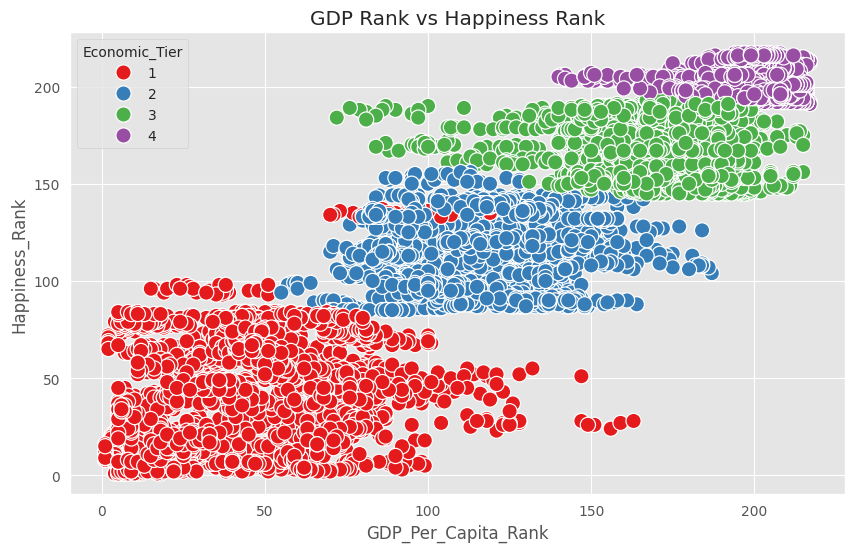

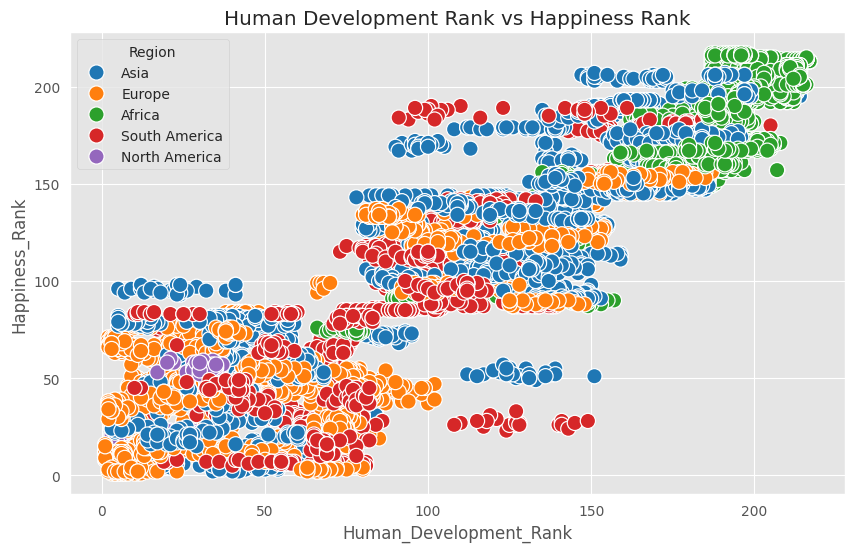

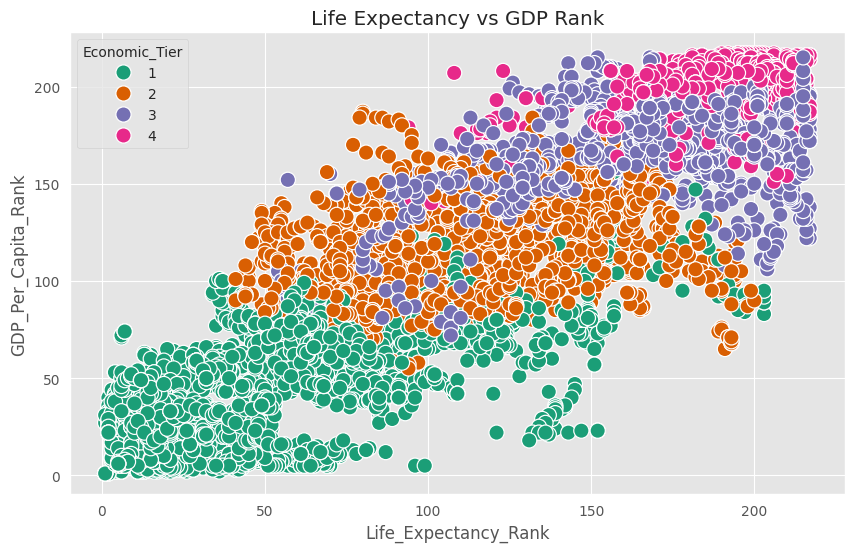

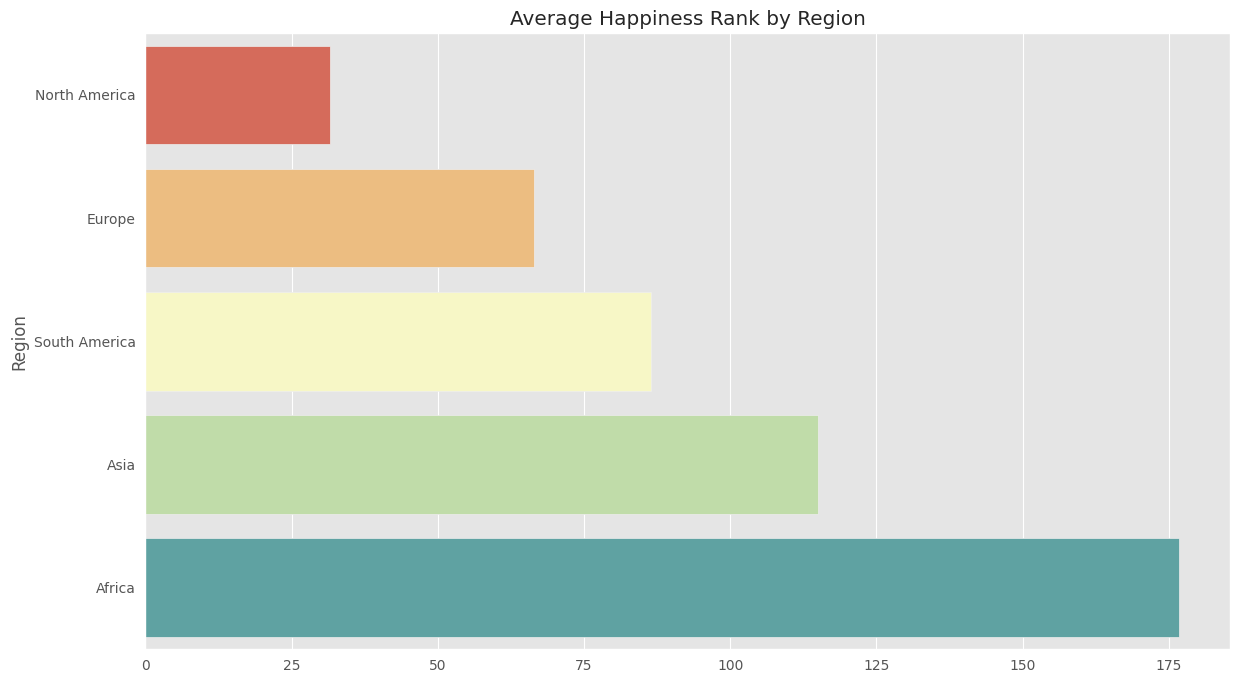

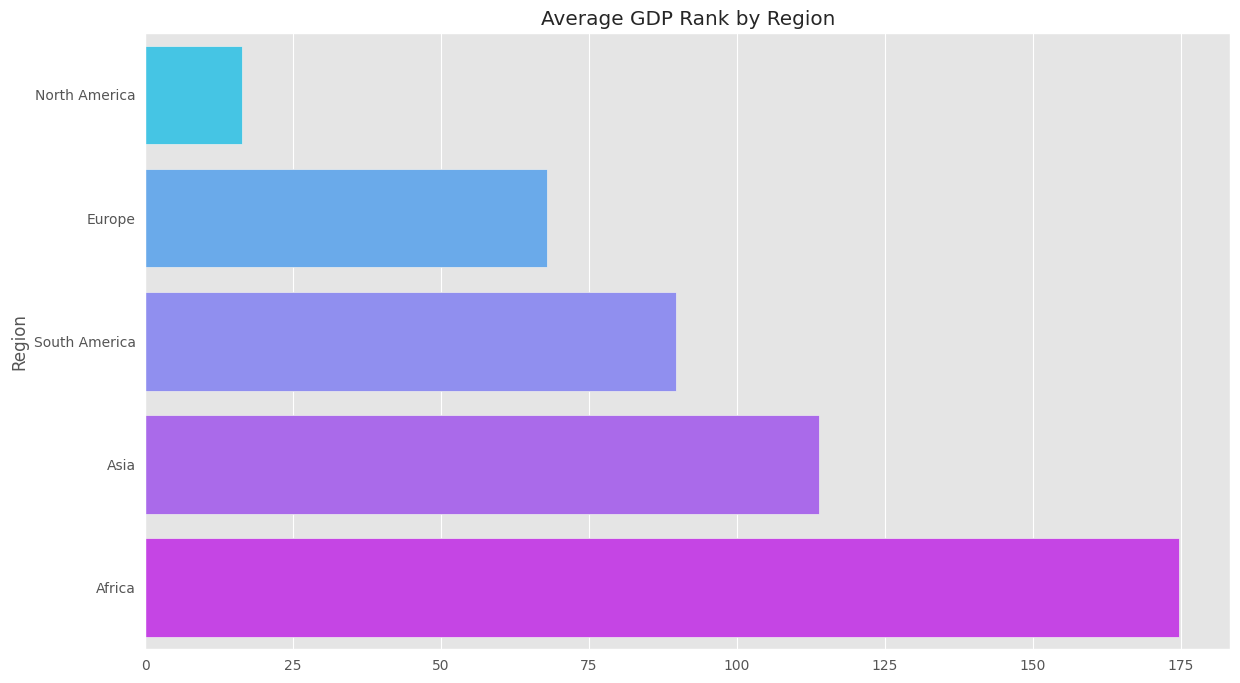

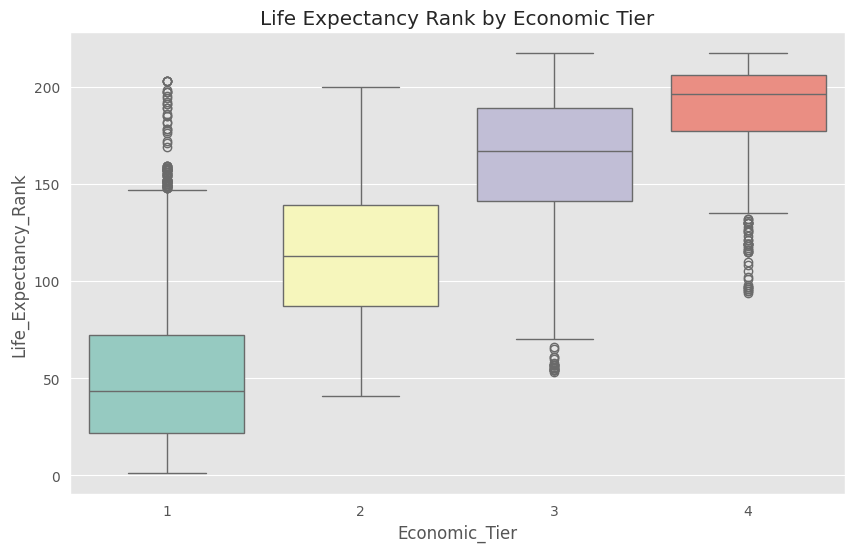

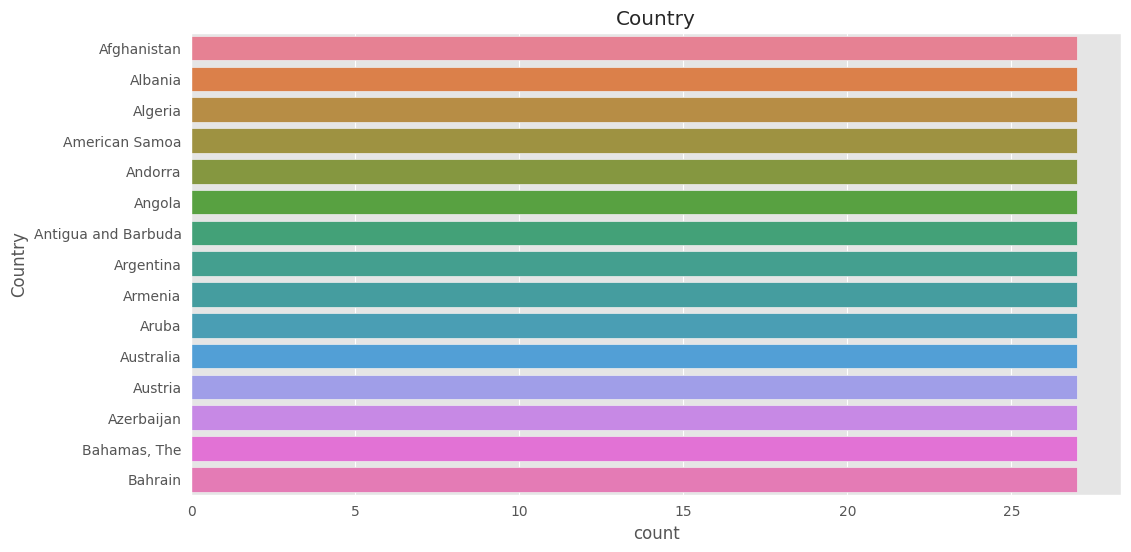

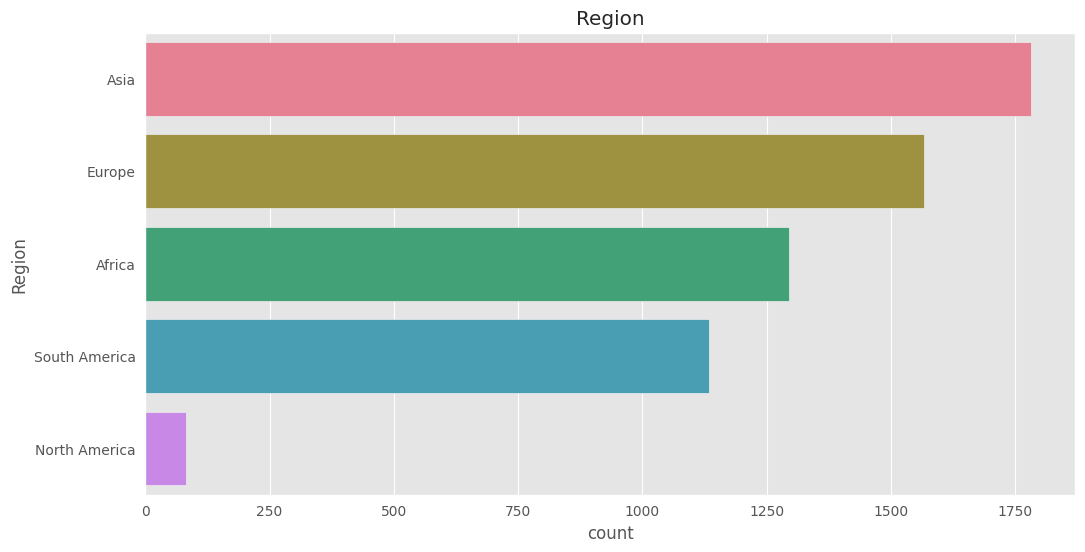

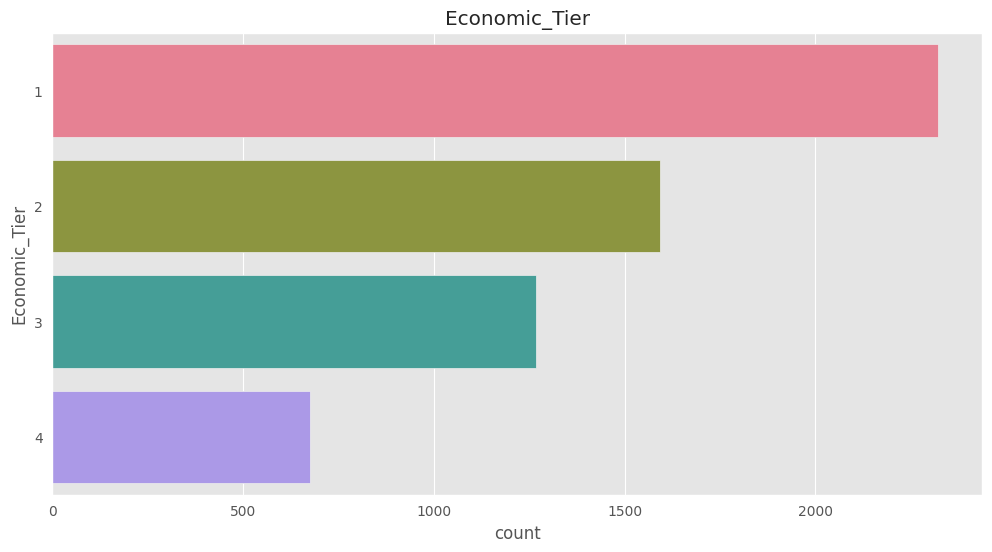

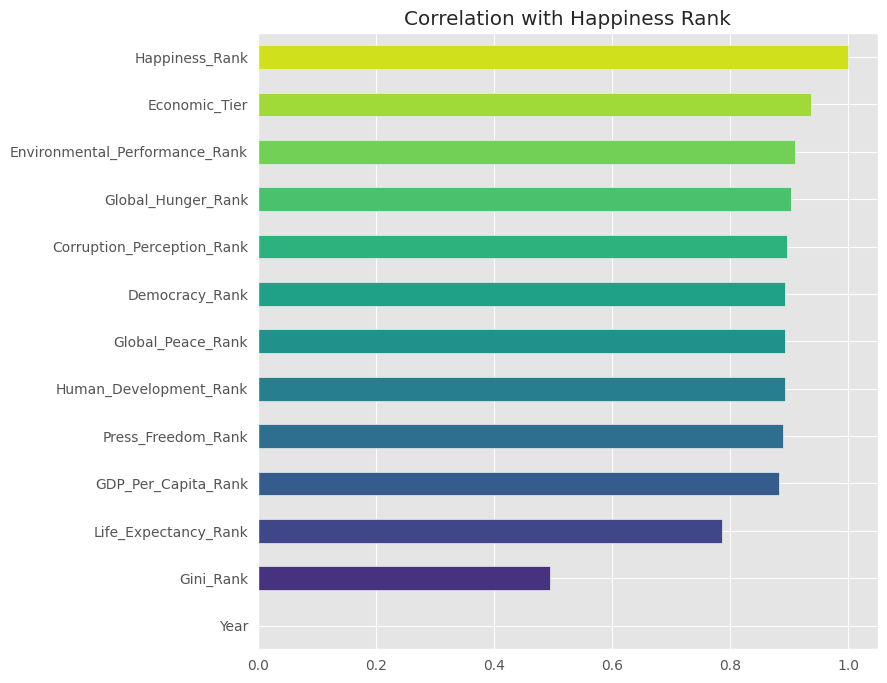

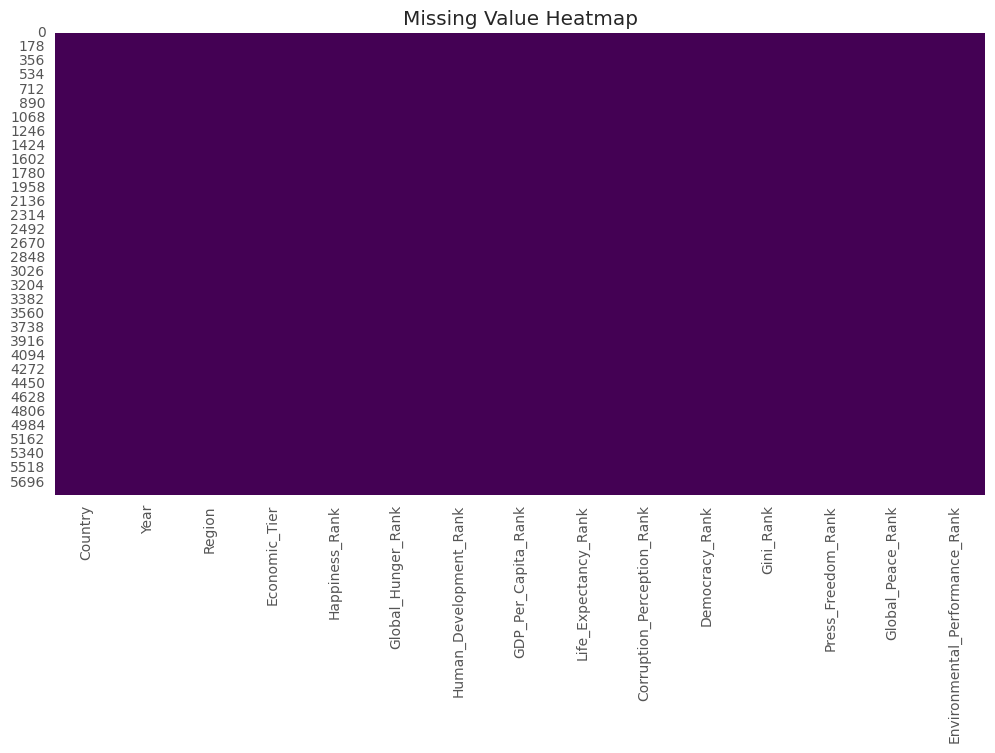


Country
Country
Afghanistan              27
Albania                  27
Algeria                  27
American Samoa           27
Andorra                  27
                         ..
Virgin Islands (U.S.)    27
West Bank and Gaza       27
Yemen, Rep.              27
Zambia                   27
Zimbabwe                 27
Name: count, Length: 217, dtype: int64

Region
Region
Asia             1782
Europe           1566
Africa           1296
South America    1134
North America      81
Name: count, dtype: int64

EDA Completed Successfully!


In [12]:
# ==========================================================
# COMPLETE EDA FOR HAPPINESS DATASET
# ==========================================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Style
sns.set_style("whitegrid")
plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

# ==========================================================
# BASIC INFORMATION
# ==========================================================

print("="*80)
print("DATASET SHAPE")
print(df.shape)

print("\n"+"="*80)
print("DATASET INFO")
print(df.info())

print("\n"+"="*80)
print("FIRST 5 ROWS")
display(df.head())

print("\n"+"="*80)
print("LAST 5 ROWS")
display(df.tail())

print("\n"+"="*80)
print("MISSING VALUES")
display(df.isnull().sum())

print("\nDuplicate Rows :",df.duplicated().sum())

print("\nStatistical Summary")
display(df.describe(include="all").T)

# ==========================================================
# NUMERIC & CATEGORICAL COLUMNS
# ==========================================================

num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include="object").columns.tolist()

print("\nNumeric Columns")
print(num_cols)

print("\nCategorical Columns")
print(cat_cols)

# ==========================================================
# MISSING VALUES
# ==========================================================

plt.figure(figsize=(12,6))
sns.barplot(
    x=df.isnull().sum().index,
    y=df.isnull().sum().values,
    palette="viridis"
)
plt.xticks(rotation=90)
plt.title("Missing Values")
plt.show()

# ==========================================================
# COUNTRY DISTRIBUTION
# ==========================================================

plt.figure(figsize=(18,8))

country=df["Country"].value_counts().head(20)

sns.barplot(
    x=country.values,
    y=country.index,
    palette="rocket"
)

plt.title("Top 20 Countries")
plt.xlabel("Frequency")
plt.show()

# ==========================================================
# REGION DISTRIBUTION
# ==========================================================

plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y="Region",
    palette="Set2"
)

plt.title("Region Distribution")
plt.show()

# ==========================================================
# YEAR DISTRIBUTION
# ==========================================================

plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="Year",
    palette="Set3"
)

plt.title("Year Distribution")
plt.show()

# ==========================================================
# ECONOMIC TIER PIE CHART
# ==========================================================

plt.figure(figsize=(8,8))

df["Economic_Tier"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("pastel")
)

plt.ylabel("")
plt.title("Economic Tier Distribution")
plt.show()

# ==========================================================
# HISTOGRAMS
# ==========================================================

df[num_cols].hist(
    figsize=(20,18),
    bins=20,
    edgecolor="black",
    color="dodgerblue"
)

plt.suptitle("Histograms",fontsize=20)
plt.show()

# ==========================================================
# BOXPLOTS
# ==========================================================

colors=["red","green","blue","orange","purple","cyan","pink","gold"]

for i,col in enumerate(num_cols):

    plt.figure(figsize=(10,3))

    sns.boxplot(
        x=df[col],
        color=colors[i%len(colors)]
    )

    plt.title(col)

    plt.show()

# ==========================================================
# VIOLIN PLOTS
# ==========================================================

for i,col in enumerate(num_cols):

    plt.figure(figsize=(10,3))

    sns.violinplot(
        x=df[col],
        color=colors[(i+2)%len(colors)]
    )

    plt.title(col)

    plt.show()

# ==========================================================
# KDE PLOTS
# ==========================================================

for i,col in enumerate(num_cols):

    plt.figure(figsize=(8,4))

    sns.kdeplot(
        data=df,
        x=col,
        fill=True,
        color=colors[(i+1)%len(colors)]
    )

    plt.title(col)

    plt.show()

# ==========================================================
# CORRELATION HEATMAP
# ==========================================================

plt.figure(figsize=(14,10))

sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

# ==========================================================
# PAIRPLOT
# ==========================================================

sns.pairplot(
    df[num_cols],
    diag_kind="hist",
    corner=True
)

plt.show()

# ==========================================================
# SCATTER PLOTS
# ==========================================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="GDP_Per_Capita_Rank",
    y="Happiness_Rank",
    hue="Economic_Tier",
    palette="Set1",
    s=120
)

plt.title("GDP Rank vs Happiness Rank")
plt.show()

# ----------------------------------------------------------

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Human_Development_Rank",
    y="Happiness_Rank",
    hue="Region",
    palette="tab10",
    s=120
)

plt.title("Human Development Rank vs Happiness Rank")
plt.show()

# ----------------------------------------------------------

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Life_Expectancy_Rank",
    y="GDP_Per_Capita_Rank",
    hue="Economic_Tier",
    palette="Dark2",
    s=120
)

plt.title("Life Expectancy vs GDP Rank")
plt.show()

# ==========================================================
# BARPLOTS
# ==========================================================

plt.figure(figsize=(14,8))

temp=df.groupby("Region")["Happiness_Rank"].mean().sort_values()

sns.barplot(
    x=temp.values,
    y=temp.index,
    palette="Spectral"
)

plt.title("Average Happiness Rank by Region")
plt.show()

# ----------------------------------------------------------

plt.figure(figsize=(14,8))

temp=df.groupby("Region")["GDP_Per_Capita_Rank"].mean().sort_values()

sns.barplot(
    x=temp.values,
    y=temp.index,
    palette="cool"
)

plt.title("Average GDP Rank by Region")
plt.show()

# ==========================================================
# BOXPLOT BY CATEGORY
# ==========================================================

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Economic_Tier",
    y="Life_Expectancy_Rank",
    palette="Set3"
)

plt.title("Life Expectancy Rank by Economic Tier")
plt.show()

# ==========================================================
# COUNTPLOTS
# ==========================================================

for col in ["Country","Region","Economic_Tier"]:

    plt.figure(figsize=(12,6))

    order=df[col].value_counts().head(15).index

    sns.countplot(
        data=df,
        y=col,
        order=order,
        palette="husl"
    )

    plt.title(col)

    plt.show()

# ==========================================================
# CORRELATION WITH TARGET
# ==========================================================

corr=df[num_cols].corr()["Happiness_Rank"].sort_values()

plt.figure(figsize=(8,8))

corr.plot(
    kind="barh",
    color=sns.color_palette("viridis",len(corr))
)

plt.title("Correlation with Happiness Rank")
plt.show()

# ==========================================================
# HEATMAP OF MISSING VALUES
# ==========================================================

plt.figure(figsize=(12,6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Value Heatmap")
plt.show()

# ==========================================================
# VALUE COUNTS OF CATEGORICAL FEATURES
# ==========================================================

for col in cat_cols:

    print("\n"+"="*60)
    print(col)
    print(df[col].value_counts())

print("\nEDA Completed Successfully!")

## Features Engineering

In [13]:
# ==========================================================
# IMPORTS
# ==========================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# ==========================================================
# TARGET
# ==========================================================

TARGET = "Economic_Tier"

# Drop identifier column if present
drop_cols = [TARGET]

if "Country" in df.columns:
    drop_cols.append("Country")

X = df.drop(columns=drop_cols)
y = df[TARGET]

print("Target:", TARGET)

# ==========================================================
# ENCODE TARGET ONLY
# ==========================================================

target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y)

print("\nClasses:")
print(target_encoder.classes_)

# ==========================================================
# TRAIN TEST SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTrain:", X_train.shape)
print("Test :", X_test.shape)

# ==========================================================
# FIND COLUMN TYPES
# ==========================================================

numeric_features = X_train.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns

categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns

print("\nNumeric Features:")
print(list(numeric_features))

print("\nCategorical Features:")
print(list(categorical_features))

# ==========================================================
# NUMERIC PIPELINE
# ==========================================================

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# ==========================================================
# CATEGORICAL PIPELINE
# ==========================================================

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# ==========================================================
# PREPROCESSOR
# ==========================================================

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# ==========================================================
# FIT ONLY TRAIN DATA
# ==========================================================

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

print("\nData preprocessing completed successfully.")
print("Train Shape:", X_train.shape)
print("Test Shape :", X_test.shape)

Target: Economic_Tier

Classes:
[1 2 3 4]

Train: (4687, 13)
Test : (1172, 13)

Numeric Features:
['Year', 'Happiness_Rank', 'Global_Hunger_Rank', 'Human_Development_Rank', 'GDP_Per_Capita_Rank', 'Life_Expectancy_Rank', 'Corruption_Perception_Rank', 'Democracy_Rank', 'Gini_Rank', 'Press_Freedom_Rank', 'Global_Peace_Rank', 'Environmental_Performance_Rank']

Categorical Features:
['Region']

Data preprocessing completed successfully.
Train Shape: (4687, 17)
Test Shape : (1172, 17)




Logistic Regression
Accuracy  : 0.9966
Precision : 0.9966
Recall    : 0.9966
F1 Score  : 0.9966

Classification Report

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       464
           1       0.99      1.00      1.00       319
           2       1.00      1.00      1.00       254
           3       1.00      1.00      1.00       135

    accuracy                           1.00      1172
   macro avg       1.00      1.00      1.00      1172
weighted avg       1.00      1.00      1.00      1172



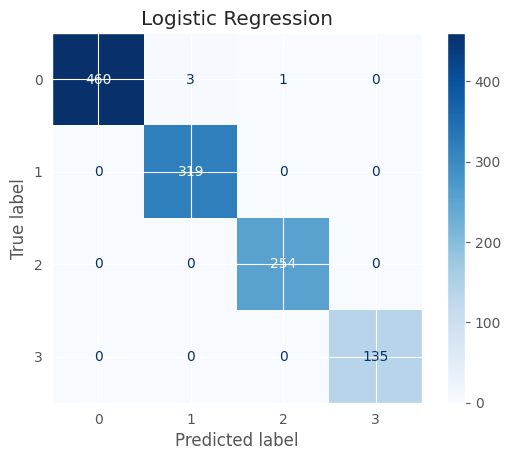

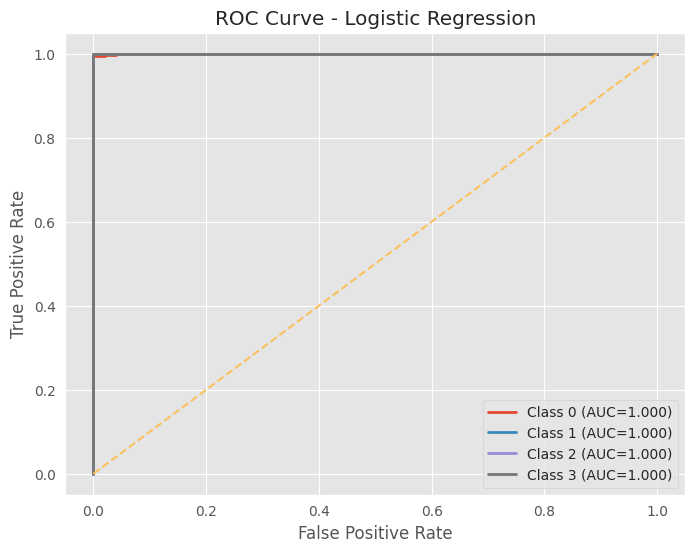



Decision Tree
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1 Score  : 1.0000

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       464
           1       1.00      1.00      1.00       319
           2       1.00      1.00      1.00       254
           3       1.00      1.00      1.00       135

    accuracy                           1.00      1172
   macro avg       1.00      1.00      1.00      1172
weighted avg       1.00      1.00      1.00      1172



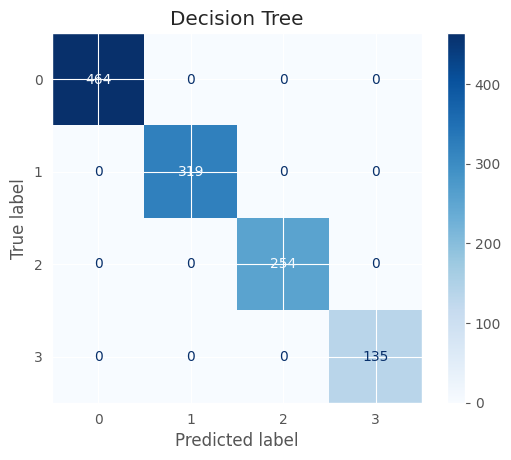

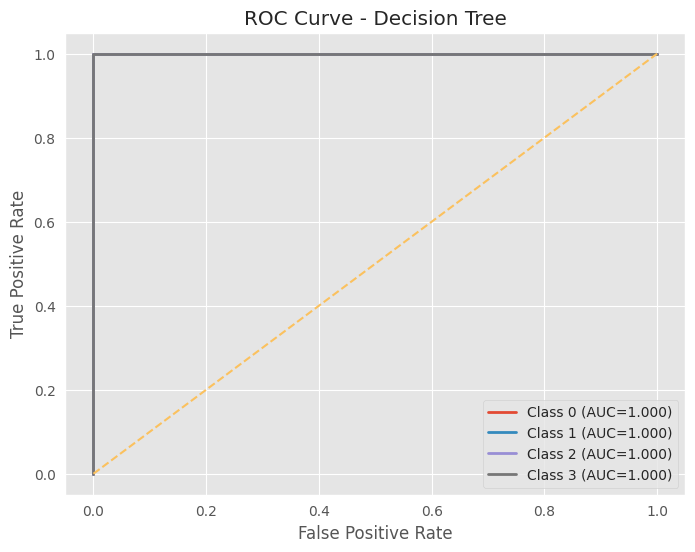



Random Forest
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1 Score  : 1.0000

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       464
           1       1.00      1.00      1.00       319
           2       1.00      1.00      1.00       254
           3       1.00      1.00      1.00       135

    accuracy                           1.00      1172
   macro avg       1.00      1.00      1.00      1172
weighted avg       1.00      1.00      1.00      1172



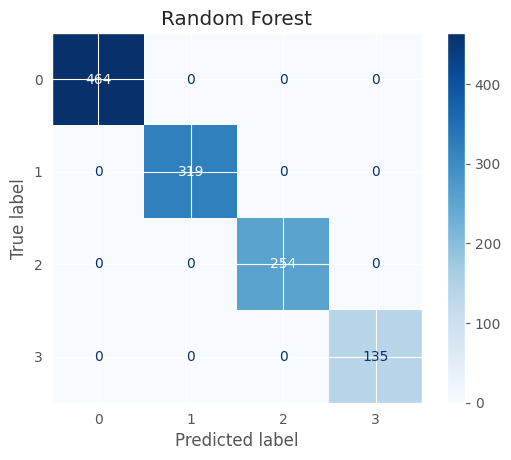

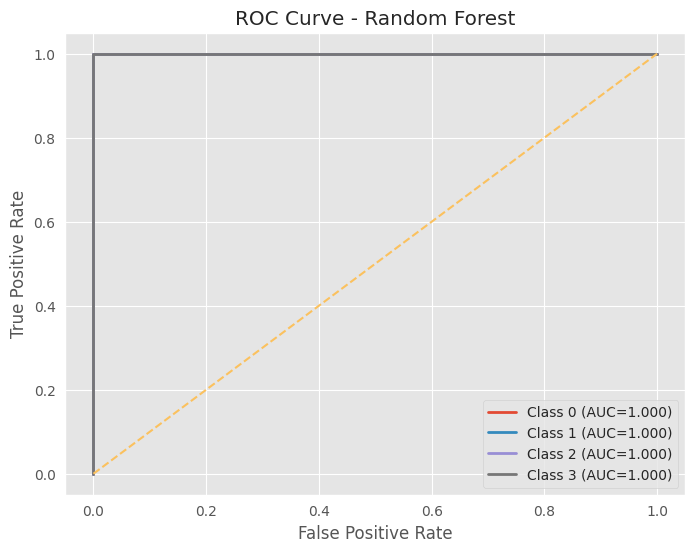



Gradient Boosting
Accuracy  : 0.9991
Precision : 0.9991
Recall    : 0.9991
F1 Score  : 0.9991

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       464
           1       1.00      1.00      1.00       319
           2       1.00      1.00      1.00       254
           3       1.00      0.99      1.00       135

    accuracy                           1.00      1172
   macro avg       1.00      1.00      1.00      1172
weighted avg       1.00      1.00      1.00      1172



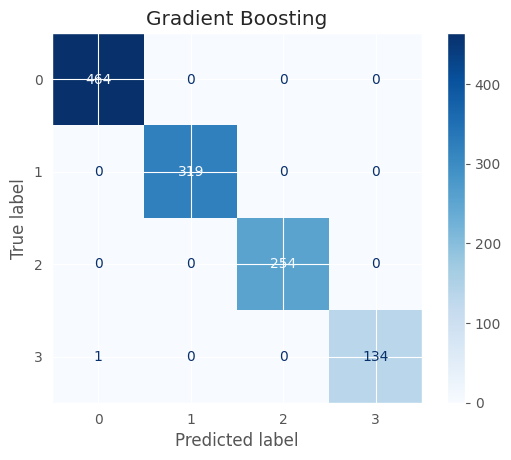

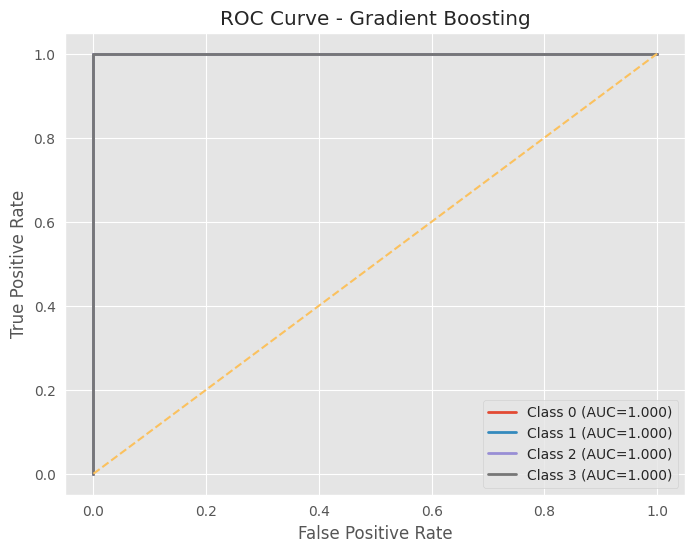



Extra Trees
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1 Score  : 1.0000

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       464
           1       1.00      1.00      1.00       319
           2       1.00      1.00      1.00       254
           3       1.00      1.00      1.00       135

    accuracy                           1.00      1172
   macro avg       1.00      1.00      1.00      1172
weighted avg       1.00      1.00      1.00      1172



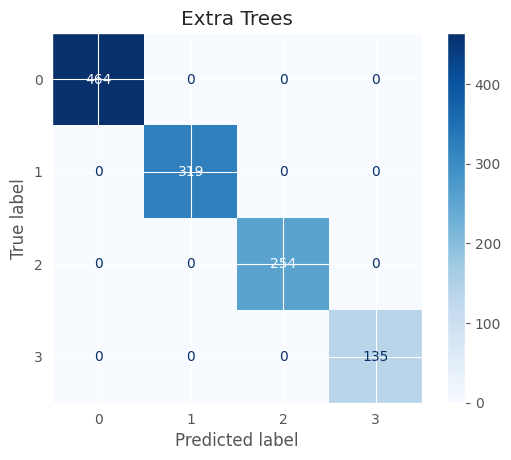

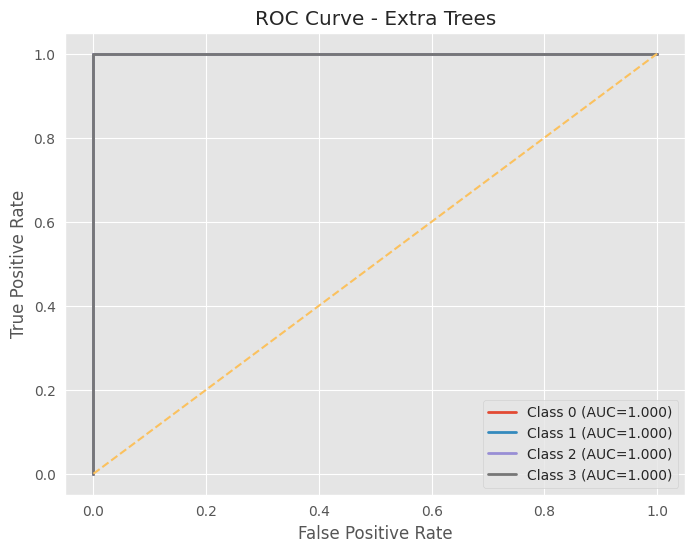



AdaBoost
Accuracy  : 0.9812
Precision : 0.9813
Recall    : 0.9812
F1 Score  : 0.9812

Classification Report

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       464
           1       0.96      0.97      0.97       319
           2       0.97      0.97      0.97       254
           3       1.00      0.99      1.00       135

    accuracy                           0.98      1172
   macro avg       0.98      0.98      0.98      1172
weighted avg       0.98      0.98      0.98      1172



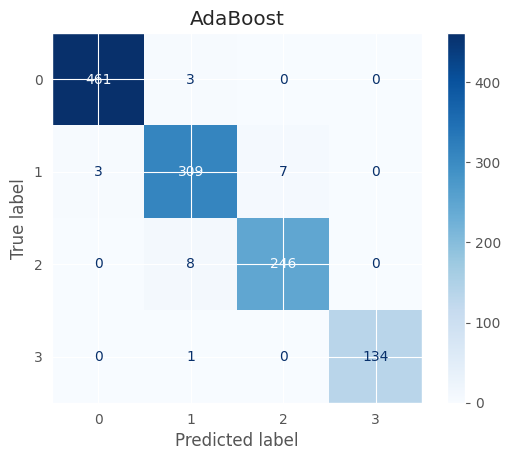

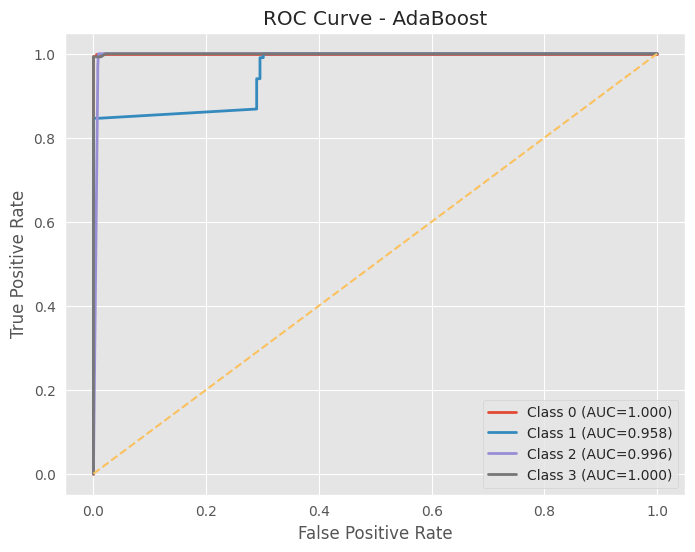



KNN
Accuracy  : 0.9983
Precision : 0.9983
Recall    : 0.9983
F1 Score  : 0.9983

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       464
           1       1.00      1.00      1.00       319
           2       1.00      0.99      1.00       254
           3       0.99      1.00      0.99       135

    accuracy                           1.00      1172
   macro avg       1.00      1.00      1.00      1172
weighted avg       1.00      1.00      1.00      1172



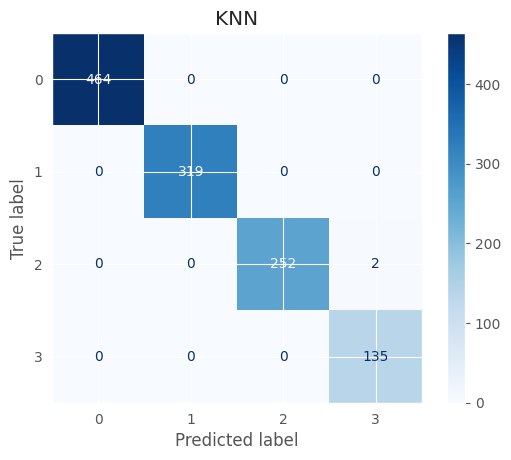

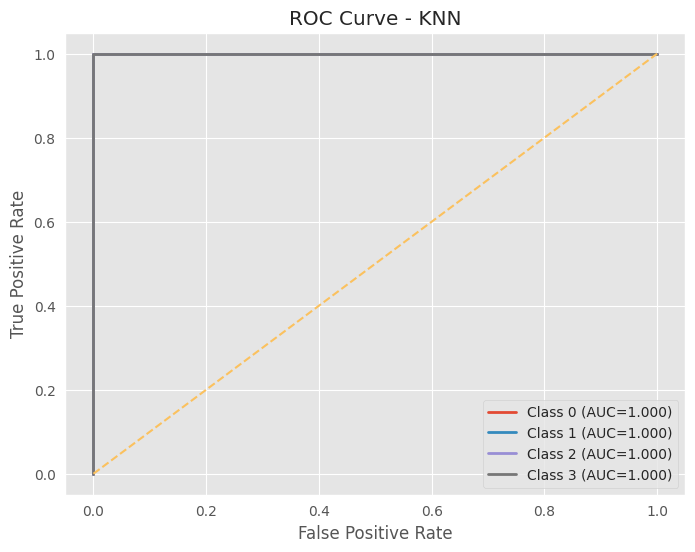



Naive Bayes
Accuracy  : 0.9846
Precision : 0.9852
Recall    : 0.9846
F1 Score  : 0.9847

Classification Report

              precision    recall  f1-score   support

           0       1.00      0.98      0.99       464
           1       0.97      1.00      0.98       319
           2       1.00      0.97      0.99       254
           3       0.95      1.00      0.97       135

    accuracy                           0.98      1172
   macro avg       0.98      0.99      0.98      1172
weighted avg       0.99      0.98      0.98      1172



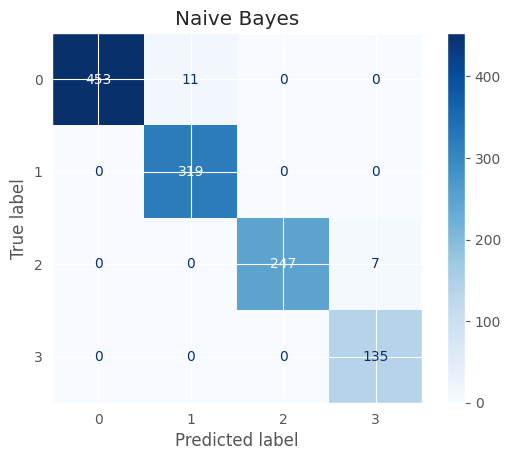

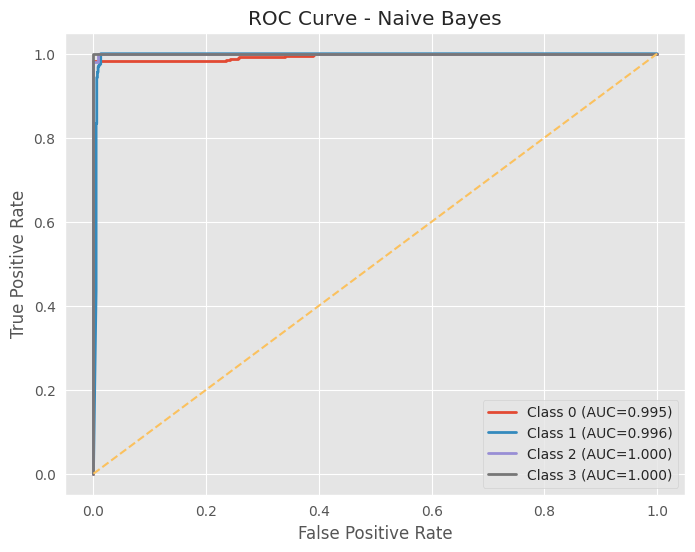



SVM
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1 Score  : 1.0000

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       464
           1       1.00      1.00      1.00       319
           2       1.00      1.00      1.00       254
           3       1.00      1.00      1.00       135

    accuracy                           1.00      1172
   macro avg       1.00      1.00      1.00      1172
weighted avg       1.00      1.00      1.00      1172



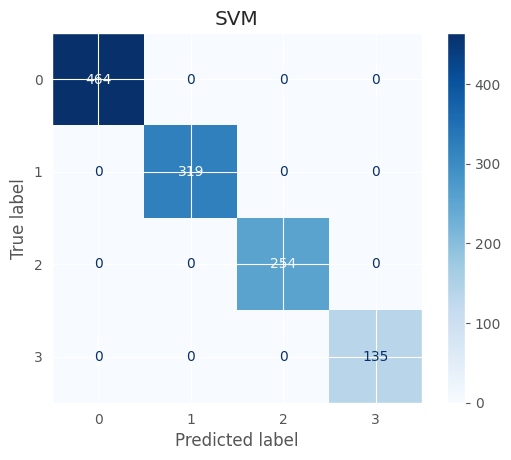

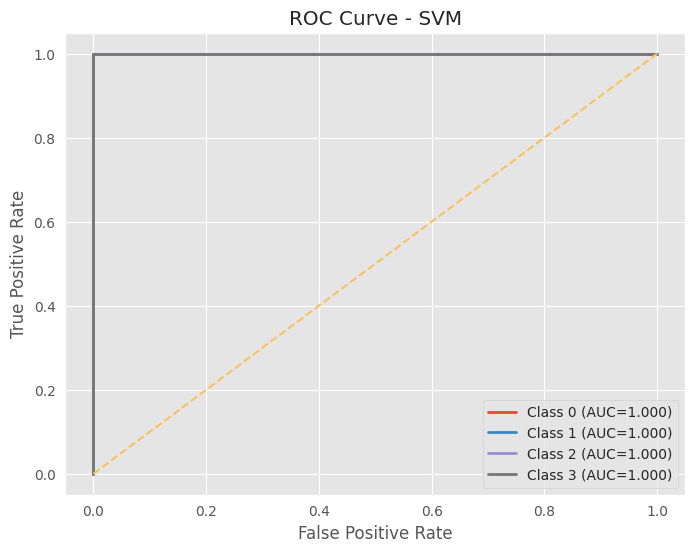



XGBoost
Accuracy  : 0.9991
Precision : 0.9992
Recall    : 0.9991
F1 Score  : 0.9991

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       464
           1       1.00      1.00      1.00       319
           2       1.00      1.00      1.00       254
           3       1.00      0.99      1.00       135

    accuracy                           1.00      1172
   macro avg       1.00      1.00      1.00      1172
weighted avg       1.00      1.00      1.00      1172



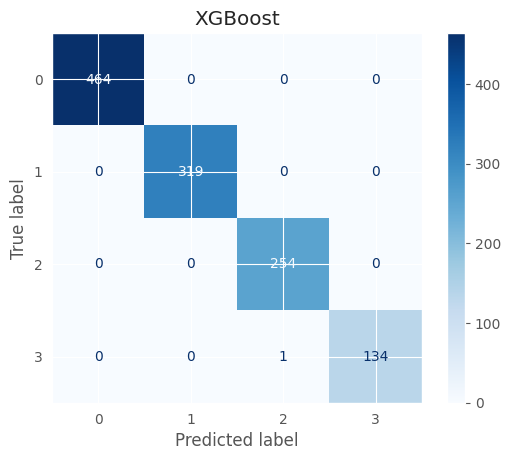

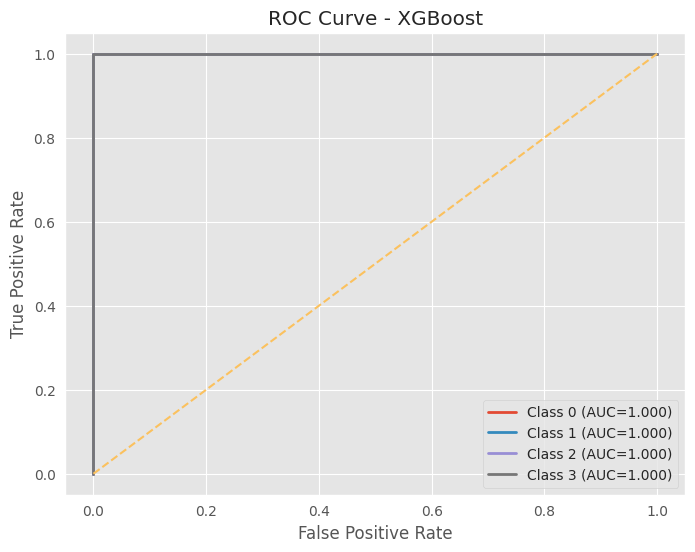



MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,1.000000,1.000000,1.000000,1.000000
1,Random Forest,1.000000,1.000000,1.000000,1.000000
2,SVM,1.000000,1.000000,1.000000,1.000000
3,Extra Trees,1.000000,1.000000,1.000000,1.000000
4,XGBoost,0.999147,0.999150,0.999147,0.999146
5,Gradient Boosting,0.999147,0.999149,0.999147,0.999146
6,KNN,0.998294,0.998318,0.998294,0.998296
7,Logistic Regression,0.996587,0.996614,0.996587,0.996586
8,Naive Bayes,0.984642,0.985249,0.984642,0.984699
9,AdaBoost,0.981229,0.981269,0.981229,0.981244



Best Model : Decision Tree
Best Accuracy : 100.0 %


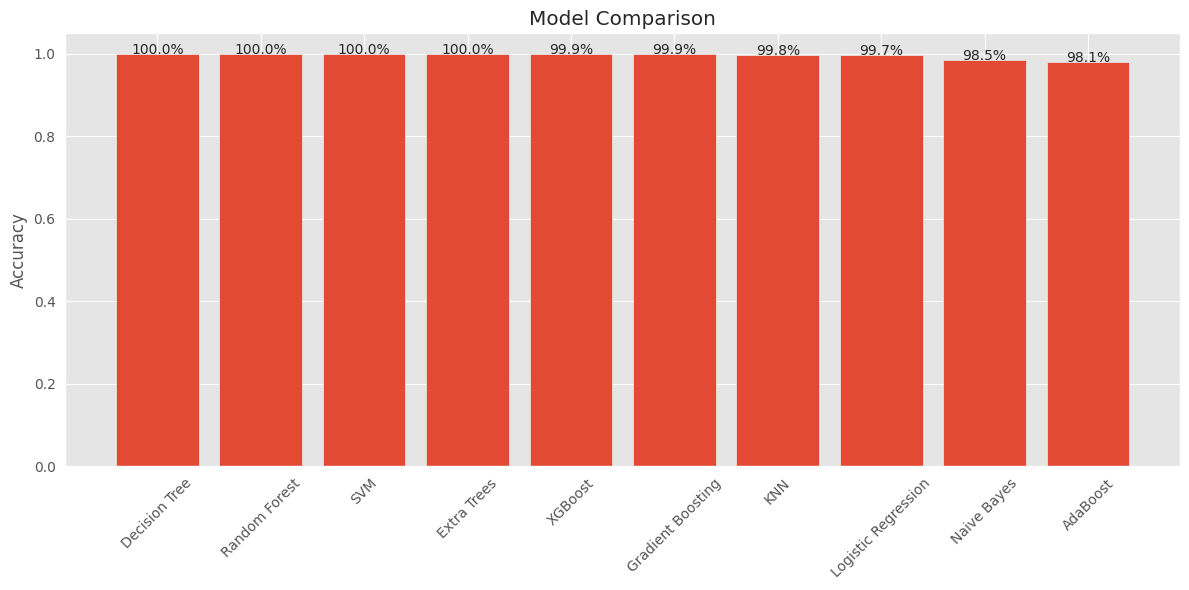

In [14]:
# ==========================================================
# PART 2 : MODEL TRAINING + EVALUATION
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

from sklearn.preprocessing import label_binarize

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

try:
    from xgboost import XGBClassifier
    xgb = True
except:
    xgb = False

# ==========================================================
# MODELS
# ==========================================================

models = {

    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(random_state=42),

    "Gradient Boosting":
        GradientBoostingClassifier(random_state=42),

    "Extra Trees":
        ExtraTreesClassifier(random_state=42),

    "AdaBoost":
        AdaBoostClassifier(random_state=42),

    "KNN":
        KNeighborsClassifier(),

    "Naive Bayes":
        GaussianNB(),

    "SVM":
        SVC(probability=True, random_state=42)

}

if xgb:
    models["XGBoost"] = XGBClassifier(
        eval_metric="mlogloss",
        random_state=42
    )

# ==========================================================
# ROC PREPARATION
# ==========================================================

classes = np.unique(y_train)

y_test_bin = label_binarize(
    y_test,
    classes=classes
)

results = []

# ==========================================================
# TRAIN EACH MODEL
# ==========================================================

for model_name, model in models.items():

    print("\n")
    print("="*80)
    print(model_name)
    print("="*80)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    results.append([
        model_name,
        accuracy,
        precision,
        recall,
        f1
    ])

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")

    print("\nClassification Report\n")

    # THIS FIXES YOUR ERROR
    print(
        classification_report(
            y_test,
            y_pred,
            zero_division=0
        )
    )

    # ======================================================
    # CONFUSION MATRIX
    # ======================================================

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(cm)

    disp.plot(cmap="Blues")

    plt.title(model_name)

    plt.show()

    # ======================================================
    # ROC CURVE
    # ======================================================

    if hasattr(model, "predict_proba"):

        probs = model.predict_proba(X_test)

        plt.figure(figsize=(8,6))

        for i in range(len(classes)):

            fpr, tpr, _ = roc_curve(
                y_test_bin[:, i],
                probs[:, i]
            )

            roc_auc = auc(fpr, tpr)

            plt.plot(
                fpr,
                tpr,
                lw=2,
                label=f"Class {classes[i]} (AUC={roc_auc:.3f})"
            )

        plt.plot(
            [0,1],
            [0,1],
            linestyle="--"
        )

        plt.xlabel("False Positive Rate")

        plt.ylabel("True Positive Rate")

        plt.title("ROC Curve - " + model_name)

        plt.legend()

        plt.grid(True)

        plt.show()

# ==========================================================
# RESULTS TABLE
# ==========================================================

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

print("\n")
print("="*80)
print("MODEL COMPARISON")
print("="*80)

display(results_df)

# ==========================================================
# BEST MODEL
# ==========================================================

best_model = results_df.iloc[0]

print("\nBest Model :", best_model["Model"])
print("Best Accuracy :", round(best_model["Accuracy"]*100,2), "%")

# ==========================================================
# ACCURACY BAR GRAPH
# ==========================================================

plt.figure(figsize=(12,6))

plt.bar(
    results_df["Model"],
    results_df["Accuracy"]
)

plt.xticks(rotation=45)

plt.ylabel("Accuracy")

plt.title("Model Comparison")

for i, v in enumerate(results_df["Accuracy"]):
    plt.text(
        i,
        v,
        f"{v*100:.1f}%",
        ha="center"
    )

plt.tight_layout()

plt.show()

## Thanks...........Please Upvote....